In [1]:
import os
import copy
import urllib.request

import torch
import torch.nn as nn
import torch.optim as optim

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

from sklearn.metrics import classification_report

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [3]:
omni_data = pd.read_csv("omni2dataset_1995_2020.csv")
omni_data['datetime'] = pd.to_datetime(
    omni_data['Year'].astype(str) + '-' +
    omni_data['Decimal Day'].astype(str) +
    ' ' +
    omni_data['Hour'].astype(str),
    format='%Y-%j %H'
)
omni_data = omni_data.drop(columns=["Year", "Decimal Day", "Hour"])
cols = ['datetime'] + [col for col in omni_data.columns if col != 'datetime']
omni_data = omni_data[cols]
omni_data.head()

,datetime,Bz_GSM,By_GSM,Bx_GSE,Kp,f10.7,AL,AU,T_proton,Np_density,V_plasma,V_Long_GSE,V_Lat_GSE,ap,P_dyn,E_field,Dst,AE
0,1995-01-01 00:00:00,-1.2,3.6,-0.6,10,72.9,-6,25,15816.0,16.3,315.0,-0.4,4.6,4,2.87,0.38,-2,32
1,1995-01-01 01:00:00,-0.7,2.6,-0.9,10,72.9,-11,26,15601.0,18.8,315.0,-0.1,3.1,4,3.28,0.22,3,38
2,1995-01-01 02:00:00,0.0,1.8,0.5,10,72.9,-12,20,20703.0,19.3,320.0,0.3,2.1,4,3.46,-0.00,6,34
3,1995-01-01 03:00:00,0.7,2.4,-3.2,0,72.9,-11,24,25094.0,16.4,317.0,1.6,2.2,0,2.90,-0.22,5,36
4,1995-01-01 04:00:00,0.5,2.1,-4.3,0,72.9,-10,19,25604.0,14.5,313.0,1.7,2.2,0,2.51,-0.16,3,31


In [4]:
fill_values = {
    "Bz_GSM": 999.9,
    "By_GSM": 999.9,
    "Bx_GSE": 999.9,
    "Kp": 99,
    "f10.7": 999.9,
    "AL": 99999,
    "AU": 99999,
    "T_proton": 9999999.,
    "Np_density": 999.9,
    "V_plasma": 9999.,
    "V_Long_GSE": 999.9,
    "V_Lat_GSE": 999.9,
    "Dst": 99999,
    "AE": 9999,
    "ap": 999,
    "P_dyn": 99.9,
    "E_field": 999.99,
}
for col in omni_data.drop(columns=["datetime"]).columns:
    omni_data[col] = omni_data[col].replace(fill_values[col], np.nan)

In [5]:
omni_dates = omni_data.copy()[["datetime"]]
omni_data = omni_data.drop(columns=["datetime"]).interpolate(method="pchip")
omni_data["datetime"] = omni_dates["datetime"]

In [6]:
omni_data = omni_data.iloc[:-1]

In [7]:
oulu_data = pd.read_csv("../data/row/oulu/OULU_1995_01_01 _00_00_2020_12_31 _23_30.csv")
oulu_data["Timestamp"] = pd.to_datetime(oulu_data["Timestamp"])
oulu_data["Timestamp"] = oulu_data["Timestamp"].dt.tz_localize(None)
oulu_data = oulu_data.rename(columns={"Timestamp": "datetime"})
oulu_data.loc[oulu_data["CorrectedCountRate[cts/min]"] < 100, "CorrectedCountRate[cts/min]"] = np.nan
oulu_data.loc[oulu_data["CorrectedCountRate[cts/min]"] > 10000, "CorrectedCountRate[cts/min]"] = np.nan
oulu_data["CorrectedCountRate[cts/min]"] = oulu_data["CorrectedCountRate[cts/min]"].interpolate(method="pchip")

In [8]:
base_url = "https://ftp.space.dtu.dk/WDC/indices/pcn/PCN_definitive/"
save_dir = "../data/row/pcn"

years = range(1995, 2021) 
downloaded_files = []

for year in years:
    filename = f"pcn{year}d.dat"
    url = base_url + filename
    save_path = os.path.join(save_dir, filename)
    
    if not os.path.exists(save_path):
        try:
            print(f"Скачивание {filename}...")
            urllib.request.urlretrieve(url, save_path)
            downloaded_files.append(save_path)
        except Exception as e:
            print(f"Ошибка загрузки {filename}: {e}")
    else:
        downloaded_files.append(save_path)

print(f"Скачано {len(downloaded_files)} файлов")

Скачано 26 файлов


In [9]:
def parse_pcn_hourly_only(filepath):
    with open(filepath, 'r') as f:
        for line in f:
            if line.startswith('DATE'):
                break
        
        data = []
        for line in f:
            if ':00:00.000' in line: 
                parts = line.strip().split()
                if len(parts) >= 4:
                    try:
                        timestamp = pd.to_datetime(parts[0] + ' ' + parts[1].split('.')[0])
                        pcn = float(parts[3])
                        if pcn != 99999.00:
                            data.append({'datetime': timestamp, 'PCN': pcn})
                    except (ValueError, IndexError):
                        continue
        
    return pd.DataFrame(data)

In [10]:
all_pcn_hourly = []
for filepath in downloaded_files:
    print(f"Парсинг {os.path.basename(filepath)}...")
    df = parse_pcn_hourly_only(filepath)
    all_pcn_hourly.append(df)

pcn_hourly = pd.concat(all_pcn_hourly, ignore_index=True)
pcn_hourly = pcn_hourly.sort_values('datetime').drop_duplicates('datetime')

Парсинг pcn1995d.dat...
Парсинг pcn1996d.dat...
Парсинг pcn1997d.dat...
Парсинг pcn1998d.dat...
Парсинг pcn1999d.dat...
Парсинг pcn2000d.dat...
Парсинг pcn2001d.dat...
Парсинг pcn2002d.dat...
Парсинг pcn2003d.dat...
Парсинг pcn2004d.dat...
Парсинг pcn2005d.dat...
Парсинг pcn2006d.dat...
Парсинг pcn2007d.dat...
Парсинг pcn2008d.dat...
Парсинг pcn2009d.dat...
Парсинг pcn2010d.dat...
Парсинг pcn2011d.dat...
Парсинг pcn2012d.dat...
Парсинг pcn2013d.dat...
Парсинг pcn2014d.dat...
Парсинг pcn2015d.dat...
Парсинг pcn2016d.dat...
Парсинг pcn2017d.dat...
Парсинг pcn2018d.dat...
Парсинг pcn2019d.dat...
Парсинг pcn2020d.dat...


In [11]:
full_dataset = pd.merge(
    oulu_data[["datetime", "CorrectedCountRate[cts/min]",]], 
    omni_data, 
    on="datetime", 
    how="inner"
)
len(full_dataset)

227927

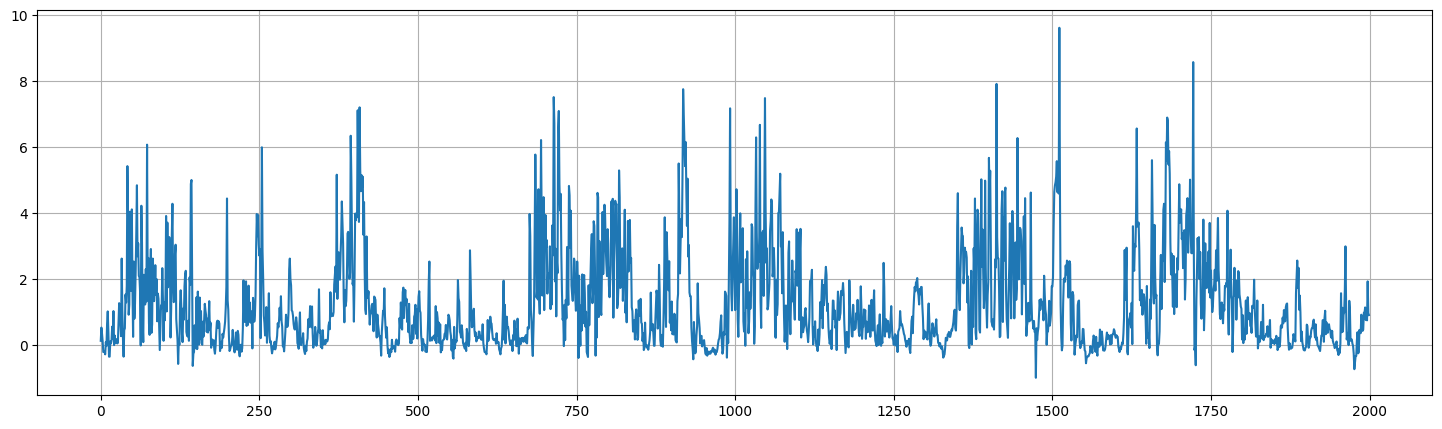

In [12]:
pcn_hourly_aligned = pd.merge(
    full_dataset[['datetime']], 
    pcn_hourly,                  
    on='datetime',
    how='left'                    
)
pcn_hourly_aligned["PCN"] = pcn_hourly_aligned["PCN"].interpolate(method="pchip")
plt.figure(figsize=(18, 5))
plt.plot(pcn_hourly_aligned["PCN"].iloc[:2000])
plt.grid()
plt.show()

In [13]:
full_dataset = pd.merge(
    full_dataset, 
    pcn_hourly_aligned[["datetime", "PCN"]], 
    on="datetime", 
    how="inner"
)
len(full_dataset)

227927

In [14]:
full_dataset.head()

,datetime,CorrectedCountRate[cts/min],Bz_GSM,By_GSM,Bx_GSE,Kp,f10.7,AL,AU,T_proton,Np_density,V_plasma,V_Long_GSE,V_Lat_GSE,ap,P_dyn,E_field,Dst,AE,PCN
0,1995-01-01 00:00:00,6371.0,-1.2,3.6,-0.6,10,72.9,-6,25,15816.0,16.3,315.0,-0.4,4.6,4,2.87,0.38,-2,32,0.14
1,1995-01-01 01:00:00,6356.0,-0.7,2.6,-0.9,10,72.9,-11,26,15601.0,18.8,315.0,-0.1,3.1,4,3.28,0.22,3,38,0.54
2,1995-01-01 02:00:00,6339.0,0.0,1.8,0.5,10,72.9,-12,20,20703.0,19.3,320.0,0.3,2.1,4,3.46,-0.00,6,34,0.35
3,1995-01-01 03:00:00,6355.0,0.7,2.4,-3.2,0,72.9,-11,24,25094.0,16.4,317.0,1.6,2.2,0,2.90,-0.22,5,36,0.12
4,1995-01-01 04:00:00,6334.0,0.5,2.1,-4.3,0,72.9,-10,19,25604.0,14.5,313.0,1.7,2.2,0,2.51,-0.16,3,31,-0.20


In [15]:
jung_data = pd.read_csv("../data/processed/jung/jung.csv", header=None)
jung_data = jung_data[[1, 2]]
jung_data.columns = ["datetime", "JUNG_flux"]
jung_data["datetime"] = pd.to_datetime(jung_data["datetime"])
jung_data["JUNG_flux"] = jung_data["JUNG_flux"].bfill()
jung_data.head()

,datetime,JUNG_flux
0,1995-01-01 00:00:00,6733.4
1,1995-01-01 01:00:00,6733.4
2,1995-01-01 02:00:00,6715.3
3,1995-01-01 03:00:00,6699.0
4,1995-01-01 04:00:00,6736.2


In [16]:
full_dataset = pd.merge(
    full_dataset, 
    jung_data[["datetime", "JUNG_flux"]], 
    on="datetime", 
    how="inner"
)
len(full_dataset)

227927

In [17]:
full_dataset = full_dataset.drop(columns=["ap", "V_Lat_GSE", "V_Long_GSE"])

IndexError: index 16 is out of bounds for axis 0 with size 16

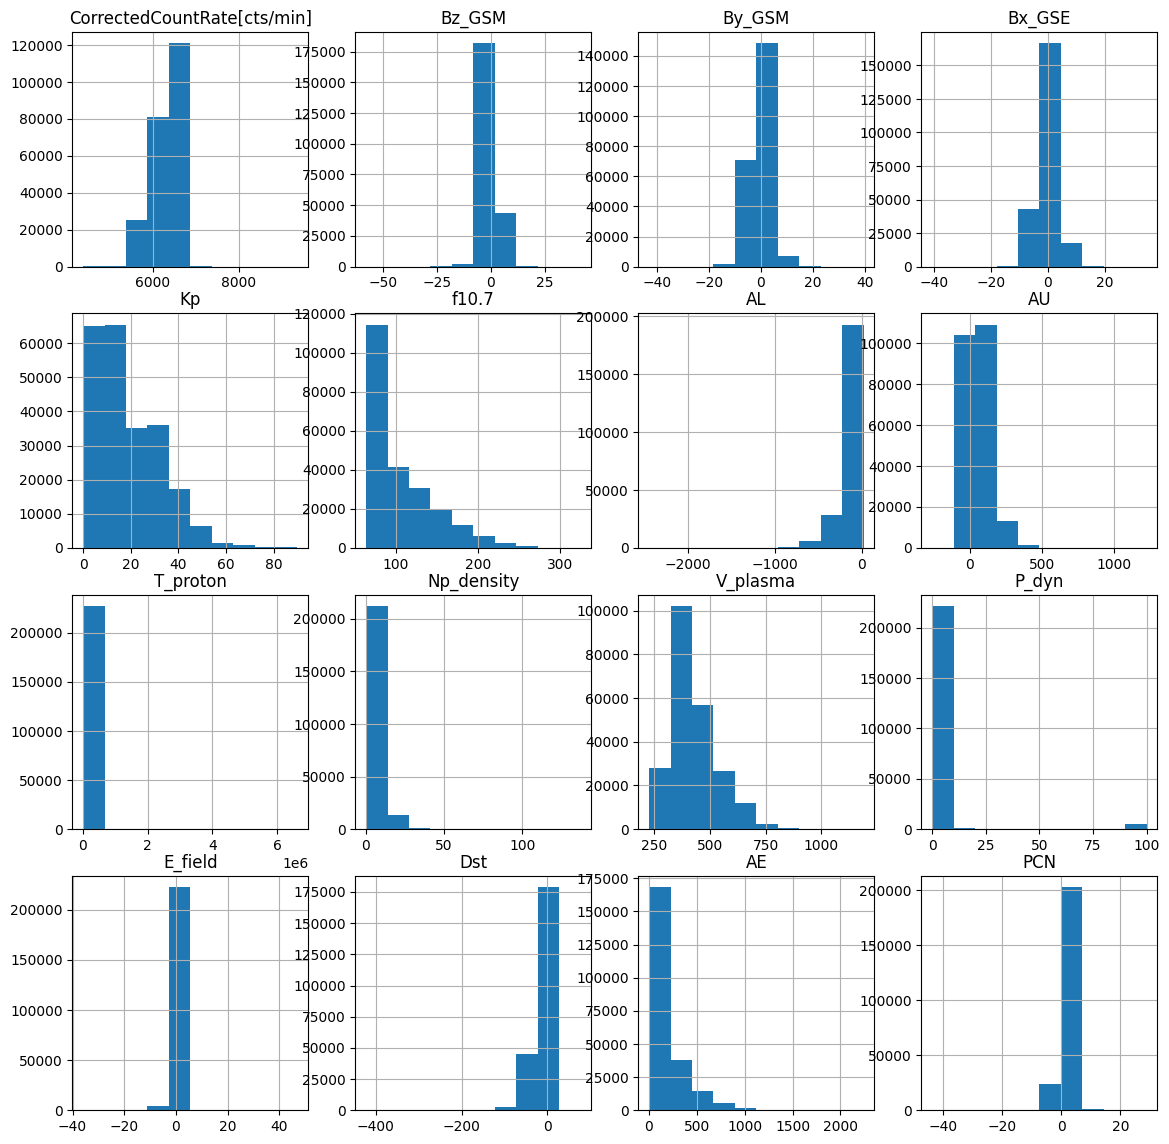

In [18]:
fig, axes = plt.subplots(4, 4, figsize=(14, 14))
axes = axes.flatten()

for ax_id, col in enumerate(full_dataset.drop(columns=["datetime"])):
    axes[ax_id].hist(np.array(full_dataset[col].to_numpy()))
    axes[ax_id].set_title(col)
    axes[ax_id].grid()
plt.tight_layout()
plt.show()

In [45]:
# log_features = ["ap", "AE", "Np_density", "T_proton"]
# for fn in log_features:
#     print(full_dataset[fn].min())

In [46]:
# for fn in log_features:
#     full_dataset[fn] = np.log1p(full_dataset[fn])

In [20]:
class CosmicRayDataset(torch.utils.data.Dataset):
    def __init__(
        self,
        df,                       
        X_window_size: int,      
        horizon: int,            
        stride: int = 1,
    ):
        self.feature_cols = [col for col in df.columns if col != 'datetime']  
        self.X_data = torch.FloatTensor(df[self.feature_cols].values.copy())
        self.y_data = torch.FloatTensor(df['Dst'].values.copy())
        
        self.X_window_size = X_window_size
        self.horizon = horizon
        self.stride = stride
        
        assert len(self.X_data) == len(self.y_data), "X and y must have same length"
        
        total_required = X_window_size + horizon
        self.num_samples = (len(self.X_data) - total_required) // stride + 1
        assert self.num_samples > 0, f"Not enough data: need {total_required}, have {len(self.X_data)}"
    
    def __len__(self) -> int:
        return self.num_samples
    
    def __getitem__(self, index):
        start_idx = index * self.stride
        
        x_end_idx = start_idx + self.X_window_size
        x_window = self.X_data[start_idx:x_end_idx]  # (X_window_size, 19)
        
        y_idx = x_end_idx + self.horizon - 1
        y_value = self.y_data[y_idx]  # скаляр
        
        return x_window, y_value

In [23]:
class HRegressor(nn.Module):
    def __init__(
        self,
        lstm_input_size,
        lstm_hidden_size,
        lstm_num_layers,
        lstm_dropout,
        dst_attention_heads,
        forecasts_len
    ):
        super().__init__()

        self.dst_attention = nn.MultiheadAttention(
            lstm_input_size,
            dst_attention_heads,
            dropout=lstm_dropout,
            batch_first=True,
        )
        self.dst_attention_norm = nn.LayerNorm(lstm_input_size)

        self.dst_lstm = nn.LSTM(
            lstm_input_size, lstm_hidden_size, lstm_num_layers,
            dropout=lstm_dropout, batch_first=True
        )

        self.bn1 = nn.BatchNorm1d(lstm_hidden_size)
        self.dropout = nn.Dropout(lstm_dropout)

        self.dst_head = nn.Sequential(
            nn.Linear(lstm_hidden_size, lstm_hidden_size),
            nn.LeakyReLU(0.1),
            nn.Dropout(lstm_dropout),
            nn.Linear(lstm_hidden_size, forecasts_len),
        )

    def forward(self, x):
        dst_attn_out, dst_attn_w = self.dst_attention(x, x, x)
        dst_x = self.dst_attention_norm(x + dst_attn_out)
        dst_out, _ = self.dst_lstm(dst_x)
        dst_features = dst_out[:, -1, :]
        # dst_features = torch.mean(dst_out, dim=1)
        dst_features = self.bn1(dst_features)
        dst_features = self.dropout(dst_features)
        dst = self.dst_head(dst_features)

        return dst.squeeze(-1), dst_attn_w

In [154]:
# clean_dataset[clean_dataset["datetime"].dt.year < 2015]

In [22]:
# train_size = int(len(clean_dataset)*0.9)
train_end = 175320
exp1 = full_dataset.copy()
exp1 = exp1.drop(columns=["datetime", "Bx_GSE"])
train_data = exp1.iloc[:train_end]
val_data = exp1.iloc[train_end:]
dst_only_scaler = MinMaxScaler(feature_range=(0, 1))
dst_only_scaler.fit_transform(train_data["Dst"].to_numpy().reshape(-1, 1))

scaler = MinMaxScaler(feature_range=(0, 1))

train_data_scaled = pd.DataFrame(scaler.fit_transform(train_data), columns=exp1.columns)
val_data_scaled = pd.DataFrame(scaler.transform(val_data), columns=exp1.columns)

In [24]:
def labeld_data(dst: np.ndarray) -> np.ndarray:
    labels = np.zeros_like(dst, dtype=np.int64)

    labels[(dst <= -20) & (dst > -50)] = 1  # Weak
    labels[(dst <= -50) & (dst > -100)] = 2 # Moderate
    labels[(dst <= -100) & (dst > -200)] = 3 # Intense
    labels[dst <= -200] = 4 # Super

    return labels

In [35]:
import os
import copy
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from sklearn.metrics import classification_report, f1_score

def labeld_data(y):
    labels = np.zeros_like(y, dtype=int)
    labels[y <= -200] = 4
    labels[(y > -200) & (y <= -100)] = 3
    labels[(y > -100) & (y <= -50)] = 2
    labels[(y > -50) & (y <= -20)] = 1
    return labels

def train_cycle(
    train_loader,
    val_loader,
    model,
    loss_fn,
    optimizer,
    scheduler,
    device,
    max_epochs,
    dst_only_scaler,
    patience=10,
    patience_delta=0.0,
    save_video=True,
    video_path="training_history.mp4",
    video_fps=5
):
    best_val_rmse = float('inf')
    best_val_f1 = 0.0
    patience_counter = 0
    best_rmse_model_state = None
    best_f1_model_state = None
    
    predictions_history = []
    targets_history = []
    epoch_numbers = []
    val_rmse_history = []

    for e in range(max_epochs):
        model.train()
        train_loss = 0

        for x, y in train_loader:
            optimizer.zero_grad()
            x, y = x.to(device), y.to(device)
            y_pred, _ = model(x)
            loss = loss_fn(y_pred, y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        train_loss /= len(train_loader)

        model.eval()
        val_loss = 0
        val_predictions_scaled = []
        val_targets_scaled = []

        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                y_pred, _ = model(x)
                loss = loss_fn(y_pred, y)
                val_loss += loss.item()
                val_predictions_scaled.extend(y_pred.detach().cpu().numpy())
                val_targets_scaled.extend(y.cpu().numpy())

        val_loss /= len(val_loader)
        
        val_predictions_scaled = np.array(val_predictions_scaled).flatten()
        val_targets_scaled = np.array(val_targets_scaled).flatten()
        
        val_predictions_nt = dst_only_scaler.inverse_transform(
            val_predictions_scaled.reshape(-1, 1)
        ).flatten()
        
        val_targets_nt = dst_only_scaler.inverse_transform(
            val_targets_scaled.reshape(-1, 1)
        ).flatten()
        
        val_rmse = np.sqrt(np.mean((val_predictions_nt - val_targets_nt) ** 2))
        val_f1 = f1_score(labeld_data(val_targets_nt), labeld_data(val_predictions_nt), average='macro')

        predictions_history.append(val_predictions_nt.copy())
        targets_history.append(val_targets_nt.copy())
        epoch_numbers.append(e + 1)
        val_rmse_history.append(val_rmse)

        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']

        if val_rmse < best_val_rmse - patience_delta:
            best_val_rmse = val_rmse
            best_rmse_model_state = copy.deepcopy(model.state_dict())
            best_rmse_epoch = e + 1
            print(f"New best RMSE model! val_rmse (nT): {best_val_rmse:.3f}")

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_f1_model_state = copy.deepcopy(model.state_dict())
            best_f1_epoch = e + 1
            print(f"New best F1 model! val_f1 (macro): {best_val_f1:.3f}")

        if val_rmse < best_val_rmse - patience_delta:
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"\nEarly stopping at epoch {e+1}")
                print(f"Best val_rmse (nT): {best_val_rmse:.3f} at epoch {best_rmse_epoch}")
                print(f"Best val_f1 (macro): {best_val_f1:.3f} at epoch {best_f1_epoch}")
                break

        if (e + 1) % 10 == 0:
            print(
                f"Epoch {e+1}: "
                f"train_loss={train_loss:.6f}, "
                f"val_loss={val_loss:.6f}, "
                f"val_rmse (nT)={val_rmse:.3f}, "
                f"val_f1={val_f1:.3f}, "
                f"lr={current_lr:.6f}"
            )

    print(f"\nBest RMSE model: epoch {best_rmse_epoch}, RMSE={best_val_rmse:.3f} nT")
    print(f"Best F1 model: epoch {best_f1_epoch}, F1 (macro)={best_val_f1:.3f}")

    # Оценка best RMSE модели
    model.load_state_dict(best_rmse_model_state)
    model.eval()
    predictions = []
    targets = []

    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(device)
            pred = model(x)[0].detach().cpu().numpy()
            predictions.extend(pred)
            targets.extend(y.numpy())

    predictions = np.array(predictions).flatten()
    targets = np.array(targets).flatten()

    predictions_nt_rmse = dst_only_scaler.inverse_transform(predictions.reshape(-1, 1)).flatten()
    targets_nt_rmse = dst_only_scaler.inverse_transform(targets.reshape(-1, 1)).flatten()

    rmse_nt = np.sqrt(np.mean((predictions_nt_rmse - targets_nt_rmse) ** 2))
    print(f"\nBest RMSE model - RMSE (nT): {rmse_nt:.3f}")
    print("Classification report (Best RMSE):")
    print(classification_report(labeld_data(targets_nt_rmse), labeld_data(predictions_nt_rmse), digits=3))

    # Оценка best F1 модели
    model.load_state_dict(best_f1_model_state)
    model.eval()
    predictions = []
    targets = []

    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(device)
            pred = model(x)[0].detach().cpu().numpy()
            predictions.extend(pred)
            targets.extend(y.numpy())

    predictions = np.array(predictions).flatten()
    targets = np.array(targets).flatten()

    predictions_nt_f1 = dst_only_scaler.inverse_transform(predictions.reshape(-1, 1)).flatten()
    targets_nt_f1 = dst_only_scaler.inverse_transform(targets.reshape(-1, 1)).flatten()

    f1_nt = f1_score(labeld_data(targets_nt_f1), labeld_data(predictions_nt_f1), average='macro')
    print(f"\nBest F1 model - F1 (macro): {f1_nt:.3f}")
    print("Classification report (Best F1):")
    print(classification_report(labeld_data(targets_nt_f1), labeld_data(predictions_nt_f1), digits=3))

    # Финальный график
    plt.figure(figsize=(14, 6))
    plt.plot(targets_nt_rmse, label="Actual Dst", alpha=0.7)
    plt.plot(predictions_nt_rmse, label=f"Best RMSE (RMSE: {rmse_nt:.1f} nT)", alpha=0.7)
    plt.plot(predictions_nt_f1, label=f"Best F1 (F1: {f1_nt:.3f})", alpha=0.7, linestyle='--')
    plt.axhline(y=-20, color='black', linestyle='--', alpha=0.7, label='Weak Storm')
    plt.axhline(y=-50, color='black', linestyle='--', alpha=0.7, label='Moderate Storm')
    plt.axhline(y=-100, color='black', linestyle='--', alpha=0.7, label='Intense Storm')
    plt.axhline(y=-200, color='black', linestyle='--', alpha=0.7, label='Super Storm')
    plt.grid()
    plt.legend()
    plt.show()

    if save_video and len(predictions_history) > 1:
        n_frames = min(len(predictions_history), 200)
        if len(predictions_history) > n_frames:
            indices = np.linspace(0, len(predictions_history)-1, n_frames, dtype=int)
        else:
            indices = range(len(predictions_history))
        
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))
        
        def animate(i):
            idx = indices[i]
            epoch = epoch_numbers[idx]
            rmse = val_rmse_history[idx]
            
            ax1.clear()
            ax2.clear()
            
            ax1.plot(targets_history[idx], label="Actual Dst", color='blue', alpha=0.7, linewidth=1)
            ax1.plot(predictions_history[idx], label=f"Predicted (RMSE: {rmse:.1f} nT)", 
                    color='red', alpha=0.7, linewidth=1)
            ax1.axhline(y=-20, color='green', linestyle='--', alpha=0.5, linewidth=0.8)
            ax1.axhline(y=-50, color='orange', linestyle='--', alpha=0.5, linewidth=0.8)
            ax1.axhline(y=-100, color='red', linestyle='--', alpha=0.5, linewidth=0.8)
            ax1.set_ylabel('Dst (nT)')
            ax1.set_title(f'Epoch {epoch} - Validation RMSE: {rmse:.1f} nT')
            ax1.legend(loc='upper right', fontsize=8)
            ax1.grid(True, alpha=0.3)
            ax1.set_ylim([-250, 50])
            
            ax2.plot(epoch_numbers[:idx+1], val_rmse_history[:idx+1], 'b-', linewidth=1.5)
            ax2.scatter([epoch], [rmse], color='red', s=50, zorder=5)
            ax2.set_xlabel('Epoch')
            ax2.set_ylabel('Validation RMSE (nT)')
            ax2.set_title('Training History')
            ax2.grid(True, alpha=0.3)
            
            plt.tight_layout()
        
        anim = animation.FuncAnimation(
            fig, animate, frames=len(indices), interval=1000//video_fps, repeat=True
        )
        
        writer = animation.FFMpegWriter(fps=video_fps)
        anim.save(video_path, writer=writer)
        plt.close(fig)
        print(f"Video saved to: {video_path}")
    
    return model, predictions_nt_rmse, targets_nt_rmse, best_f1_model_state, best_rmse_model_state

In [79]:
def event_based_classification(predictions_nt, targets_nt, min_duration=6, overlap_threshold=0.3):
    def get_storm_intervals(dst_series, threshold_min, threshold_max):
        mask = (dst_series <= threshold_min) & (dst_series > threshold_max)
        intervals = []
        start = None
        for i, val in enumerate(mask):
            if val and start is None:
                start = i
            elif not val and start is not None:
                duration = i - start
                if duration >= min_duration:
                    intervals.append((start, i - 1))
                start = None
        if start is not None:
            duration = len(mask) - start
            if duration >= min_duration:
                intervals.append((start, len(mask) - 1))
        return intervals
    
    def compute_overlap(actual_interval, pred_interval):
        start = max(actual_interval[0], pred_interval[0])
        end = min(actual_interval[1], pred_interval[1])
        if end < start:
            return 0.0
        overlap = end - start + 1
        actual_duration = actual_interval[1] - actual_interval[0] + 1
        return overlap / actual_duration
    
    def evaluate_class(actual_intervals, pred_intervals):
        if not actual_intervals:
            return None
        
        matched_actual = set()
        matched_pred = set()
        
        for i_actual, actual in enumerate(actual_intervals):
            best_overlap = 0.0
            best_i_pred = -1
            for i_pred, pred in enumerate(pred_intervals):
                if i_pred in matched_pred:
                    continue
                overlap = compute_overlap(actual, pred)
                if overlap > best_overlap:
                    best_overlap = overlap
                    best_i_pred = i_pred
            
            if best_overlap >= overlap_threshold:
                matched_actual.add(i_actual)
                matched_pred.add(best_i_pred)
        
        tp = len(matched_actual)
        fp = len(pred_intervals) - len(matched_pred)
        fn = len(actual_intervals) - len(matched_actual)
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
        
        return {'precision': precision, 'recall': recall, 'f1': f1, 'tp': tp, 'fp': fp, 'fn': fn}
    
    thresholds = {
        'Weak': (-30, -50),
        'Moderate': (-50, -100),
        'Intense': (-100, -200),
        'Super': (-200, -float('inf'))
    }
    
    results = {}
    total_tp = 0
    total_fp = 0
    total_fn = 0
    
    print("Event-based classification (min_duration={}h, overlap_threshold={}%):".format(min_duration, overlap_threshold*100))
    print("-" * 70)
    print(f"{'Class':<12} {'Actual':<8} {'Predicted':<10} {'TP':<6} {'FP':<6} {'FN':<6} {'Precision':<10} {'Recall':<10} {'F1':<10}")
    print("-" * 70)
    
    for class_name, (thresh_min, thresh_max) in thresholds.items():
        actual_intervals = get_storm_intervals(targets_nt, thresh_min, thresh_max)
        pred_intervals = get_storm_intervals(predictions_nt, thresh_min, thresh_max)
        
        if not actual_intervals:
            print(f"{class_name:<12} {len(actual_intervals):<8} {len(pred_intervals):<10} {'N/A':<6} {'N/A':<6} {'N/A':<6} {'N/A':<10} {'N/A':<10} {'N/A':<10}")
            continue
        
        metrics = evaluate_class(actual_intervals, pred_intervals)
        
        if metrics:
            results[class_name] = metrics
            print(f"{class_name:<12} {len(actual_intervals):<8} {len(pred_intervals):<10} {metrics['tp']:<6} {metrics['fp']:<6} {metrics['fn']:<6} {metrics['precision']:<10.3f} {metrics['recall']:<10.3f} {metrics['f1']:<10.3f}")
            total_tp += metrics['tp']
            total_fp += metrics['fp']
            total_fn += metrics['fn']
    
    total_precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
    total_recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
    total_f1 = 2 * total_precision * total_recall / (total_precision + total_recall) if (total_precision + total_recall) > 0 else 0
    
    print("-" * 70)
    print(f"{'Overall':<12} {'Total':<8} {'Total':<10} {total_tp:<6} {total_fp:<6} {total_fn:<6} {total_precision:<10.3f} {total_recall:<10.3f} {total_f1:<10.3f}")
    
    return results

In [ ]:
X_WINDOW_SIZE = 36
HORIZON = 48
BATCH_SIZE = 512
INITIAL_LR = 0.001
MAX_EPOCHES = 3000
PATIENCE = 30
PATIENCE_DELTA = 0.001

train_dataset = CosmicRayDataset(df=train_data_scaled, X_window_size=X_WINDOW_SIZE, horizon=HORIZON)
val_dataset = CosmicRayDataset(df=val_data_scaled, X_window_size=X_WINDOW_SIZE, horizon=HORIZON)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

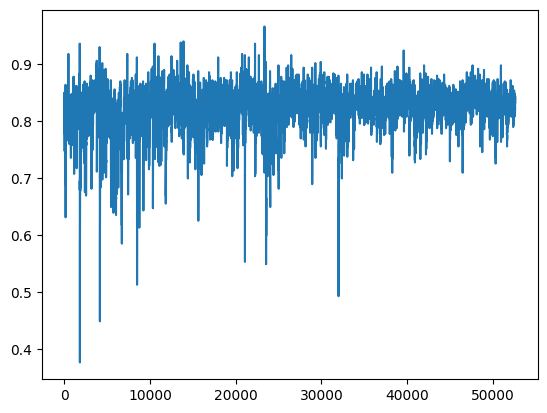

In [ ]:
plt.plot(val_data_scaled["Dst"])

In [430]:
model = HRegressor(
    lstm_input_size=15,
    lstm_hidden_size=50,
    lstm_num_layers=1,
    lstm_dropout=0.0,
    dst_attention_heads=3,
    forecasts_len=1
).to(device)
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=INITIAL_LR) 
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
print(sum(i.numel() for i in model.parameters()))

17091


New best model! val_rmse (nT): 120.440
New best model! val_rmse (nT): 94.107
New best model! val_rmse (nT): 50.557
New best model! val_rmse (nT): 32.508
New best model! val_rmse (nT): 23.446
New best model! val_rmse (nT): 18.552
New best model! val_rmse (nT): 17.873
Epoch 10: train_loss=0.001761, val_loss=0.003274, val_rmse (nT)=28.563, lr=0.001000
New best model! val_rmse (nT): 17.818
New best model! val_rmse (nT): 17.084
New best model! val_rmse (nT): 16.732
New best model! val_rmse (nT): 16.570
New best model! val_rmse (nT): 16.504
Epoch 20: train_loss=0.001511, val_loss=0.001129, val_rmse (nT)=16.788, lr=0.000500
New best model! val_rmse (nT): 16.049
New best model! val_rmse (nT): 15.980
Epoch 30: train_loss=0.001339, val_loss=0.001052, val_rmse (nT)=16.205, lr=0.000250
Epoch 40: train_loss=0.001233, val_loss=0.001157, val_rmse (nT)=17.001, lr=0.000063
Epoch 50: train_loss=0.001219, val_loss=0.001249, val_rmse (nT)=17.666, lr=0.000016

Early stopping at epoch 56
Best val_rmse (nT):

/home/zorinep/workdir/practice-2026/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/zorinep/workdir/practice-2026/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/zorinep/workdir/practice-2026/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 

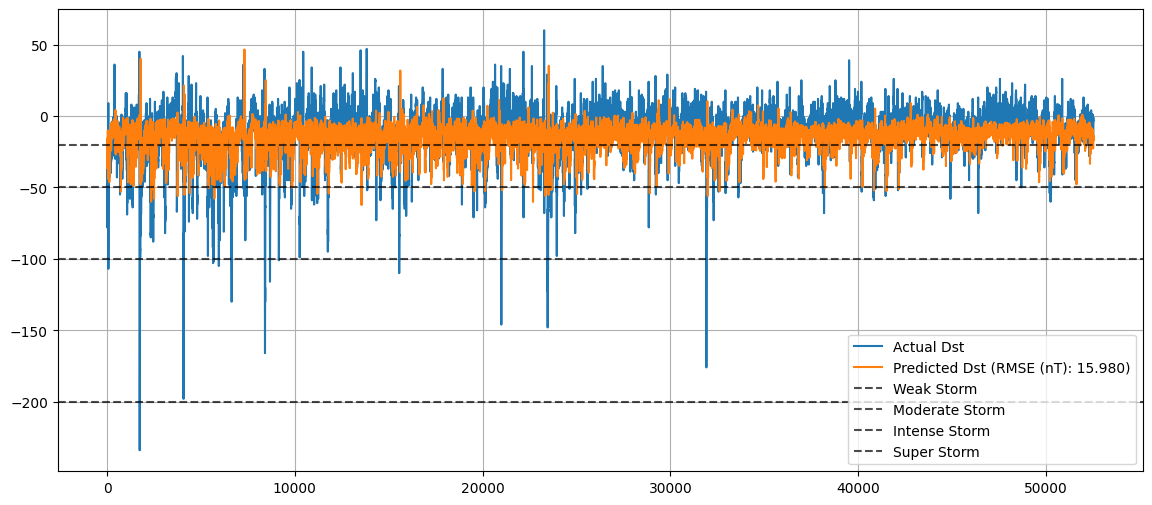

In [86]:
result = train_cycle(
    train_loader=train_loader,
    val_loader=val_loader,
    model=model,
    loss_fn=loss_fn,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    max_epochs=MAX_EPOCHES,
    dst_only_scaler=dst_only_scaler,
    patience=PATIENCE,
    patience_delta=PATIENCE_DELTA,
) 

17091
New best model! val_rmse (nT): 154.309
New best model! val_rmse (nT): 101.703
New best model! val_rmse (nT): 76.884
New best model! val_rmse (nT): 45.260
New best model! val_rmse (nT): 31.317
New best model! val_rmse (nT): 27.722
New best model! val_rmse (nT): 26.703
New best model! val_rmse (nT): 25.255
New best model! val_rmse (nT): 24.506
New best model! val_rmse (nT): 23.984
Epoch 10: train_loss=0.001735, val_loss=0.002303, val_rmse (nT)=23.984, lr=0.001000
New best model! val_rmse (nT): 23.610
New best model! val_rmse (nT): 23.059
New best model! val_rmse (nT): 22.586
New best model! val_rmse (nT): 22.363
Epoch 20: train_loss=0.001626, val_loss=0.002710, val_rmse (nT)=26.013, lr=0.000500
New best model! val_rmse (nT): 18.823
Epoch 30: train_loss=0.001290, val_loss=0.001512, val_rmse (nT)=19.439, lr=0.000250
Epoch 40: train_loss=0.001197, val_loss=0.001726, val_rmse (nT)=20.765, lr=0.000063
Epoch 50: train_loss=0.001177, val_loss=0.001852, val_rmse (nT)=21.508, lr=0.000031

E

/home/zorinep/workdir/practice-2026/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/zorinep/workdir/practice-2026/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/zorinep/workdir/practice-2026/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 

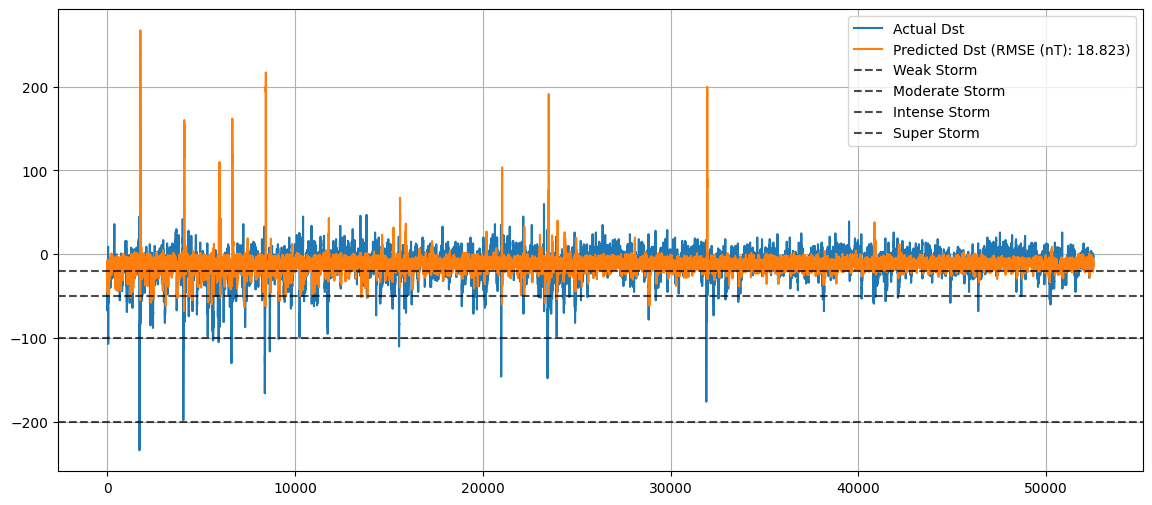

In [95]:
X_WINDOW_SIZE = 48
HORIZON = 48
BATCH_SIZE = 512
INITIAL_LR = 0.001
MAX_EPOCHES = 3000
PATIENCE = 30
PATIENCE_DELTA = 0.001

train_dataset = CosmicRayDataset(df=train_data_scaled, X_window_size=X_WINDOW_SIZE, horizon=HORIZON)
val_dataset = CosmicRayDataset(df=val_data_scaled, X_window_size=X_WINDOW_SIZE, horizon=HORIZON)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

model = HRegressor(
    lstm_input_size=15,
    lstm_hidden_size=50,
    lstm_num_layers=1,
    lstm_dropout=0.0,
    dst_attention_heads=15,
    forecasts_len=1
).to(device)
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=INITIAL_LR) 
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
print(sum(i.numel() for i in model.parameters()))

result = train_cycle(
    train_loader=train_loader,
    val_loader=val_loader,
    model=model,
    loss_fn=loss_fn,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    max_epochs=MAX_EPOCHES,
    dst_only_scaler=dst_only_scaler,
    patience=PATIENCE,
    patience_delta=PATIENCE_DELTA,
) 

30531
New best model! val_rmse (nT): 99.256
New best model! val_rmse (nT): 68.000
New best model! val_rmse (nT): 50.815
New best model! val_rmse (nT): 36.711
New best model! val_rmse (nT): 28.116
New best model! val_rmse (nT): 23.503
New best model! val_rmse (nT): 20.791
New best model! val_rmse (nT): 19.113
New best model! val_rmse (nT): 18.513
Epoch 10: train_loss=0.001726, val_loss=0.001379, val_rmse (nT)=18.560, lr=0.001000
New best model! val_rmse (nT): 17.801
Epoch 20: train_loss=0.001406, val_loss=0.001383, val_rmse (nT)=18.589, lr=0.000500
Epoch 30: train_loss=0.001177, val_loss=0.001753, val_rmse (nT)=20.942, lr=0.000125
Epoch 40: train_loss=0.001101, val_loss=0.001516, val_rmse (nT)=19.471, lr=0.000031

Early stopping at epoch 46
Best val_rmse (nT): 17.801
RMSE (nT): 17.801
Pointwise classification report:
              precision    recall  f1-score   support

           0      0.817     0.858     0.837     40605
           1      0.375     0.346     0.360     10566
         

/home/zorinep/workdir/practice-2026/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/zorinep/workdir/practice-2026/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/zorinep/workdir/practice-2026/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 

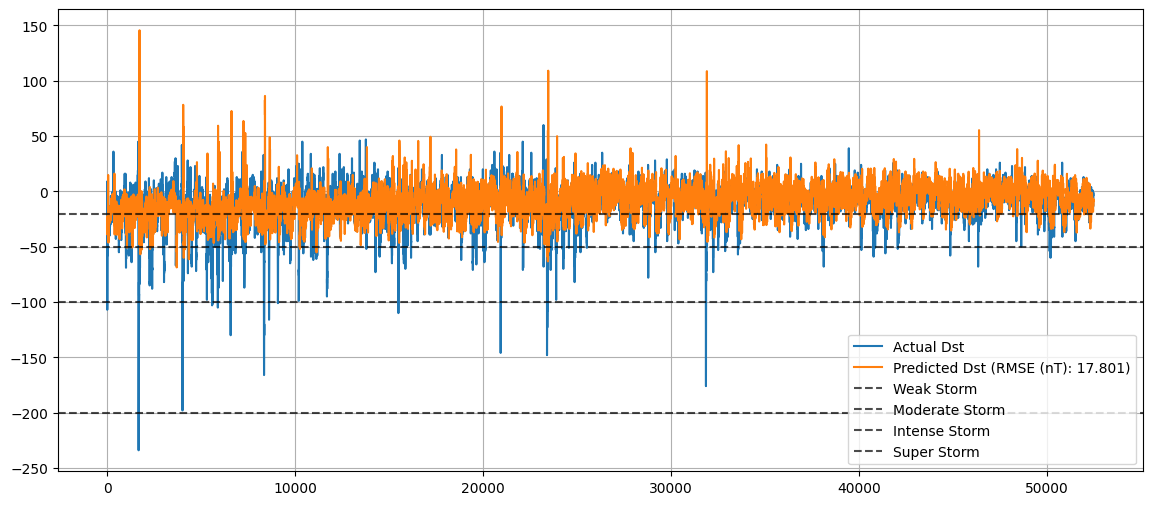

In [97]:
X_WINDOW_SIZE = 96
HORIZON = 48
BATCH_SIZE = 512
INITIAL_LR = 0.001
MAX_EPOCHES = 3000
PATIENCE = 30
PATIENCE_DELTA = 0.001

train_dataset = CosmicRayDataset(df=train_data_scaled, X_window_size=X_WINDOW_SIZE, horizon=HORIZON)
val_dataset = CosmicRayDataset(df=val_data_scaled, X_window_size=X_WINDOW_SIZE, horizon=HORIZON)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

model = HRegressor(
    lstm_input_size=15,
    lstm_hidden_size=70,
    lstm_num_layers=1,
    lstm_dropout=0.0,
    dst_attention_heads=15,
    forecasts_len=1
).to(device)
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=INITIAL_LR) 
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
print(sum(i.numel() for i in model.parameters()))

result = train_cycle(
    train_loader=train_loader,
    val_loader=val_loader,
    model=model,
    loss_fn=loss_fn,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    max_epochs=MAX_EPOCHES,
    dst_only_scaler=dst_only_scaler,
    patience=PATIENCE,
    patience_delta=PATIENCE_DELTA,
) 

17091
New best model! val_rmse (nT): 16.994
New best model! val_rmse (nT): 15.903
New best model! val_rmse (nT): 15.682
New best model! val_rmse (nT): 15.418
New best model! val_rmse (nT): 14.469
Epoch 10: train_loss=0.001576, val_loss=0.000838, val_rmse (nT)=14.469, lr=0.001000
New best model! val_rmse (nT): 14.432
New best model! val_rmse (nT): 14.289
Epoch 20: train_loss=0.001314, val_loss=0.000848, val_rmse (nT)=14.551, lr=0.000500
Epoch 30: train_loss=0.001219, val_loss=0.000878, val_rmse (nT)=14.809, lr=0.000250

Early stopping at epoch 34
Best val_rmse (nT): 14.289
RMSE (nT): 14.289
Pointwise classification report:
              precision    recall  f1-score   support

           0      0.827     0.942     0.881     40605
           1      0.554     0.322     0.407     10609
           2      0.460     0.039     0.072      1175
           3      0.000     0.000     0.000       121
           4      0.000     0.000     0.000         3

    accuracy                          0.795 

/home/zorinep/workdir/practice-2026/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/zorinep/workdir/practice-2026/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/zorinep/workdir/practice-2026/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 

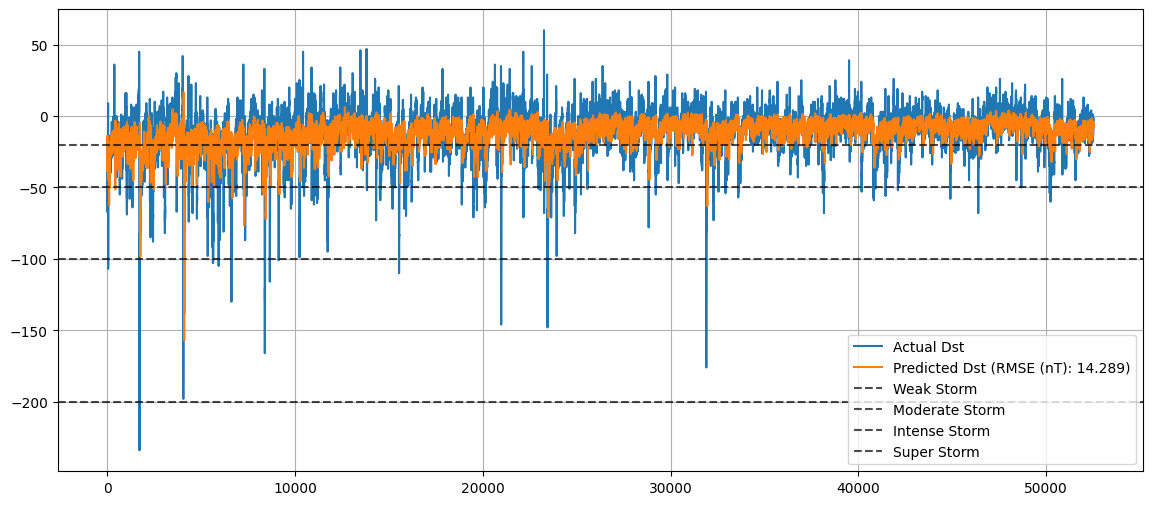

In [ ]:
X_WINDOW_SIZE = 48
HORIZON = 48
BATCH_SIZE = 512
INITIAL_LR = 0.001
MAX_EPOCHES = 3000
PATIENCE = 15
PATIENCE_DELTA = 0.01

train_dataset = CosmicRayDataset(df=train_data_scaled, X_window_size=X_WINDOW_SIZE, horizon=HORIZON)
val_dataset = CosmicRayDataset(df=val_data_scaled, X_window_size=X_WINDOW_SIZE, horizon=HORIZON)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

model = HRegressor(
    lstm_input_size=15,
    lstm_hidden_size=50,
    lstm_num_layers=1,
    lstm_dropout=0.0,
    dst_attention_heads=1,
    forecasts_len=1
).to(device)
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=INITIAL_LR) 
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
print(sum(i.numel() for i in model.parameters()))

result = train_cycle(
    train_loader=train_loader,
    val_loader=val_loader,
    model=model,
    loss_fn=loss_fn,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    max_epochs=MAX_EPOCHES,
    dst_only_scaler=dst_only_scaler,
    patience=PATIENCE,
    patience_delta=PATIENCE_DELTA,
) 

30531
New best model! val_rmse (nT): 23.511
New best model! val_rmse (nT): 17.085
New best model! val_rmse (nT): 15.674
New best model! val_rmse (nT): 14.890
Epoch 10: train_loss=0.001503, val_loss=0.000896, val_rmse (nT)=14.965, lr=0.001000
New best model! val_rmse (nT): 14.494
Epoch 20: train_loss=0.001224, val_loss=0.000869, val_rmse (nT)=14.733, lr=0.001000
New best model! val_rmse (nT): 14.437
New best model! val_rmse (nT): 14.395
Epoch 30: train_loss=0.000943, val_loss=0.000870, val_rmse (nT)=14.746, lr=0.000500
Epoch 40: train_loss=0.000742, val_loss=0.000883, val_rmse (nT)=14.855, lr=0.000125

Early stopping at epoch 43
Best val_rmse (nT): 14.395
RMSE (nT): 14.395
Pointwise classification report:
              precision    recall  f1-score   support

           0      0.857     0.875     0.866     40605
           1      0.482     0.495     0.488     10566
           2      0.382     0.047     0.084      1170
           3      0.000     0.000     0.000       121
           4   

/home/zorinep/workdir/practice-2026/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/zorinep/workdir/practice-2026/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/zorinep/workdir/practice-2026/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 

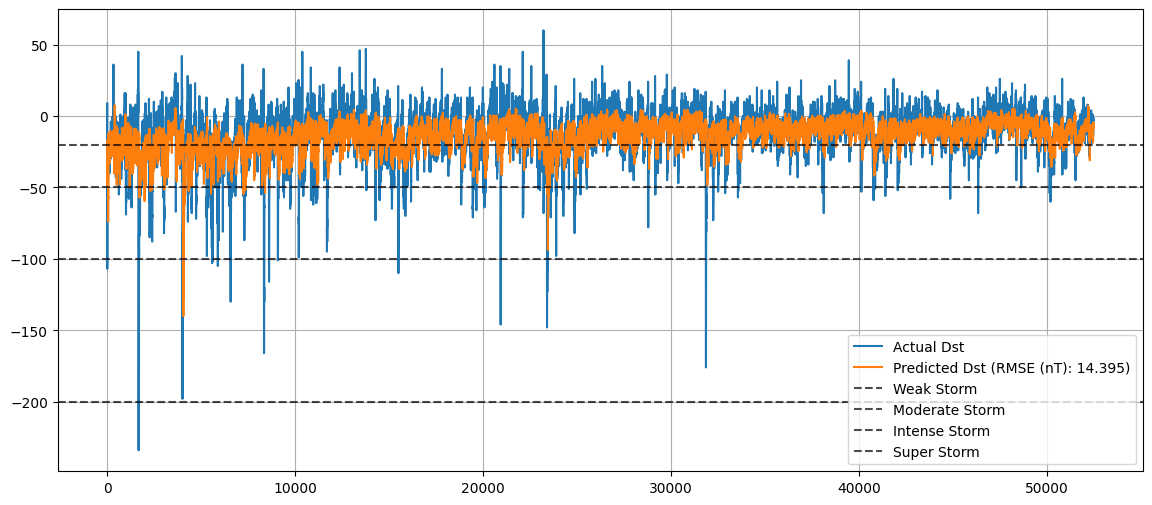

In [175]:
X_WINDOW_SIZE = 96
HORIZON = 48
BATCH_SIZE = 512
INITIAL_LR = 0.001
MAX_EPOCHES = 3000
PATIENCE = 15
PATIENCE_DELTA = 0.01

train_dataset = CosmicRayDataset(df=train_data_scaled, X_window_size=X_WINDOW_SIZE, horizon=HORIZON)
val_dataset = CosmicRayDataset(df=val_data_scaled, X_window_size=X_WINDOW_SIZE, horizon=HORIZON)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

model = HRegressor(
    lstm_input_size=15,
    lstm_hidden_size=70,
    lstm_num_layers=1,
    lstm_dropout=0.0,
    dst_attention_heads=15,
    forecasts_len=1
).to(device)
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=INITIAL_LR) 
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
print(sum(i.numel() for i in model.parameters()))

result = train_cycle(
    train_loader=train_loader,
    val_loader=val_loader,
    model=model,
    loss_fn=loss_fn,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    max_epochs=MAX_EPOCHES,
    dst_only_scaler=dst_only_scaler,
    patience=PATIENCE,
    patience_delta=PATIENCE_DELTA,
) 

14849
New best model! val_rmse (nT): 33.431
New best model! val_rmse (nT): 22.450
New best model! val_rmse (nT): 21.417
New best model! val_rmse (nT): 20.973
Epoch 10: train_loss=0.001525, val_loss=0.002130, val_rmse (nT)=23.031, lr=0.001000
New best model! val_rmse (nT): 19.971
New best model! val_rmse (nT): 19.893
New best model! val_rmse (nT): 19.677
New best model! val_rmse (nT): 18.960
New best model! val_rmse (nT): 18.914
New best model! val_rmse (nT): 18.552
Epoch 20: train_loss=0.001332, val_loss=0.001382, val_rmse (nT)=18.552, lr=0.001000
New best model! val_rmse (nT): 18.516
New best model! val_rmse (nT): 17.900
New best model! val_rmse (nT): 17.628
New best model! val_rmse (nT): 17.264
Epoch 30: train_loss=0.001233, val_loss=0.001197, val_rmse (nT)=17.264, lr=0.000750
New best model! val_rmse (nT): 16.060
New best model! val_rmse (nT): 16.044
New best model! val_rmse (nT): 15.751
Epoch 40: train_loss=0.001155, val_loss=0.001039, val_rmse (nT)=16.082, lr=0.000750
Epoch 50: tr

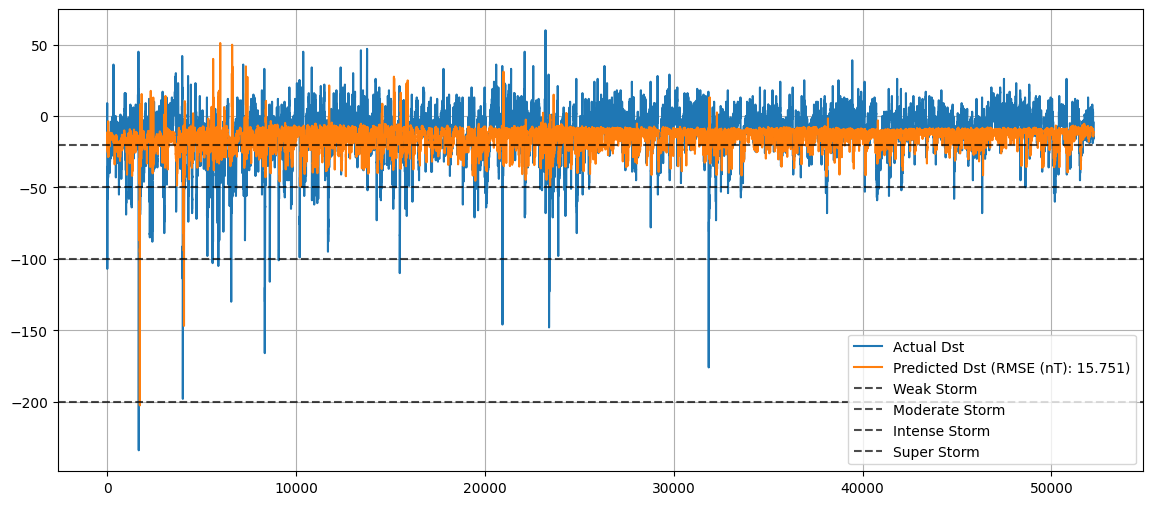

In [66]:
X_WINDOW_SIZE = 24*4
HORIZON = 48
BATCH_SIZE = 512
INITIAL_LR = 0.001
MAX_EPOCHES = 3000
PATIENCE = 15
PATIENCE_DELTA = 0.01

train_dataset = CosmicRayDataset(df=train_data_scaled, X_window_size=X_WINDOW_SIZE, horizon=HORIZON)
val_dataset = CosmicRayDataset(df=val_data_scaled, X_window_size=X_WINDOW_SIZE, horizon=HORIZON)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=True)

model = HRegressor(
    lstm_input_size=14,
    lstm_hidden_size=50,
    lstm_num_layers=1,
    lstm_dropout=0.0,
    dst_attention_heads=14,
    forecasts_len=1
).to(device)
loss_fn = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=INITIAL_LR) 
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.75, patience=5)
print(sum(i.numel() for i in model.parameters()))

result = train_cycle(
    train_loader=train_loader,
    val_loader=val_loader,
    model=model,
    loss_fn=loss_fn,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    dst_only_scaler=dst_only_scaler,
    max_epochs=MAX_EPOCHES,
    patience=PATIENCE,
    patience_delta=PATIENCE_DELTA,
)

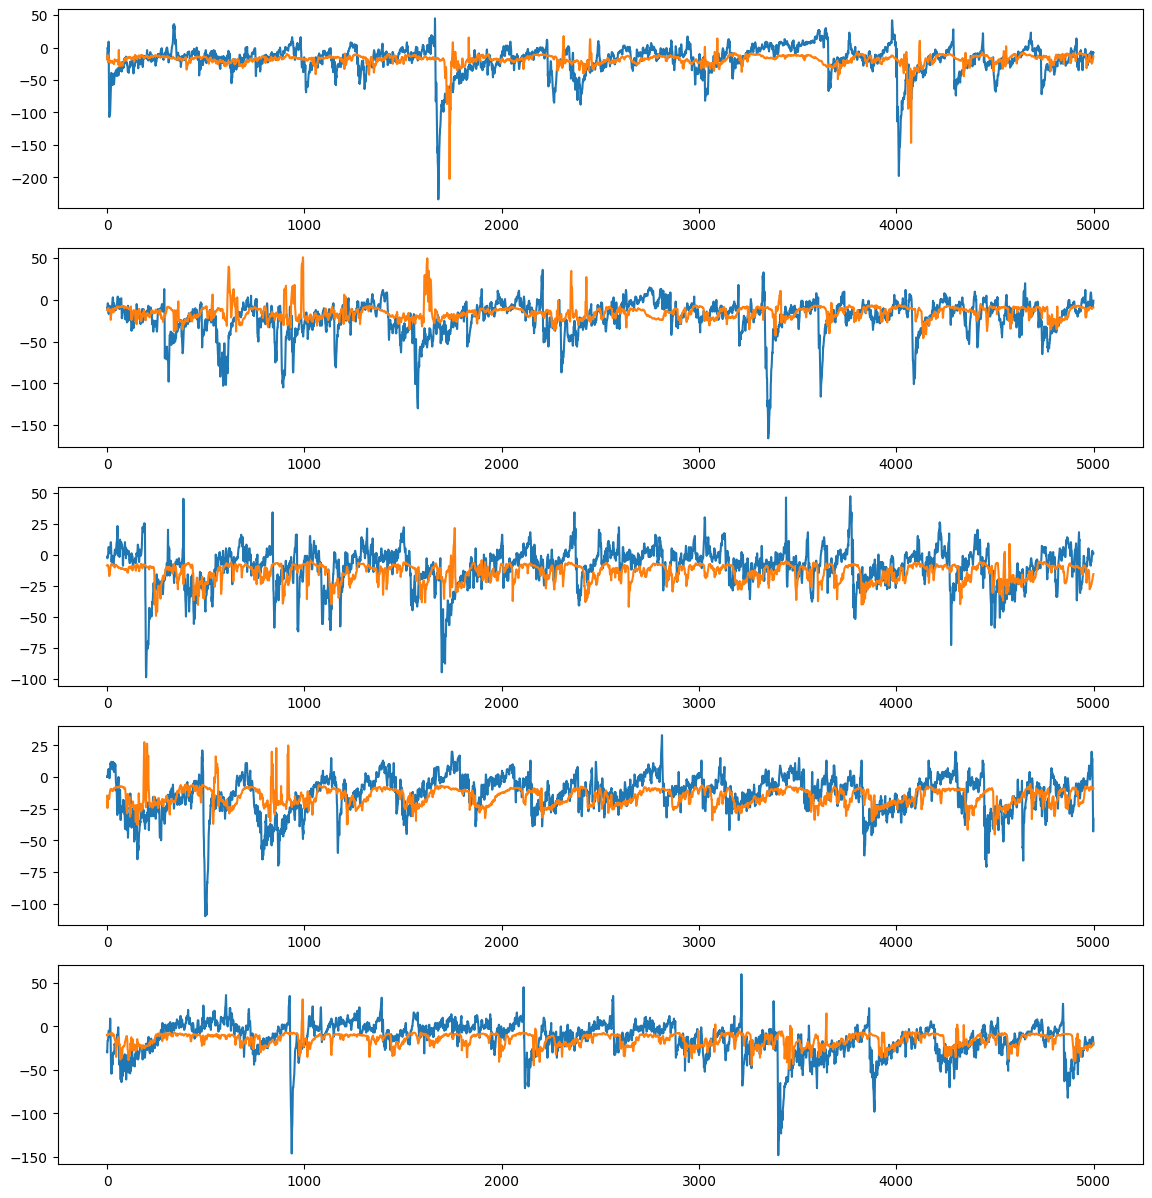

In [67]:
_, axes = plt.subplots(5, 1, figsize=(14, 15))
axes = axes.flatten()

predict = result[1]
target = result[2]
for id, i in enumerate([
    (0, 5000),
    (5000, 10000),
    (10000, 15000),
    (15000, 20000),
    (20000, 25000),
    ]):
    start, end = i
    axes[id].plot(target[start:end])
    axes[id].plot(predict[start:end])


17421
New best model! val_rmse (nT): 104.307
New best model! val_rmse (nT): 94.590
New best model! val_rmse (nT): 89.024
New best model! val_rmse (nT): 71.086
New best model! val_rmse (nT): 62.400
New best model! val_rmse (nT): 51.979
New best model! val_rmse (nT): 45.009
New best model! val_rmse (nT): 39.556
New best model! val_rmse (nT): 34.886
New best model! val_rmse (nT): 31.352
Epoch 10: train_loss=0.001696, val_loss=0.003948, val_rmse (nT)=31.352, lr=0.001000
New best model! val_rmse (nT): 29.237
New best model! val_rmse (nT): 28.274
New best model! val_rmse (nT): 28.245
New best model! val_rmse (nT): 27.954
New best model! val_rmse (nT): 26.687
Epoch 20: train_loss=0.001647, val_loss=0.003096, val_rmse (nT)=27.767, lr=0.001000
New best model! val_rmse (nT): 26.188
New best model! val_rmse (nT): 25.594
New best model! val_rmse (nT): 23.166
New best model! val_rmse (nT): 20.955
New best model! val_rmse (nT): 19.536
New best model! val_rmse (nT): 18.391
New best model! val_rmse (n

/home/zorinep/workdir/practice-2026/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/zorinep/workdir/practice-2026/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/zorinep/workdir/practice-2026/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 

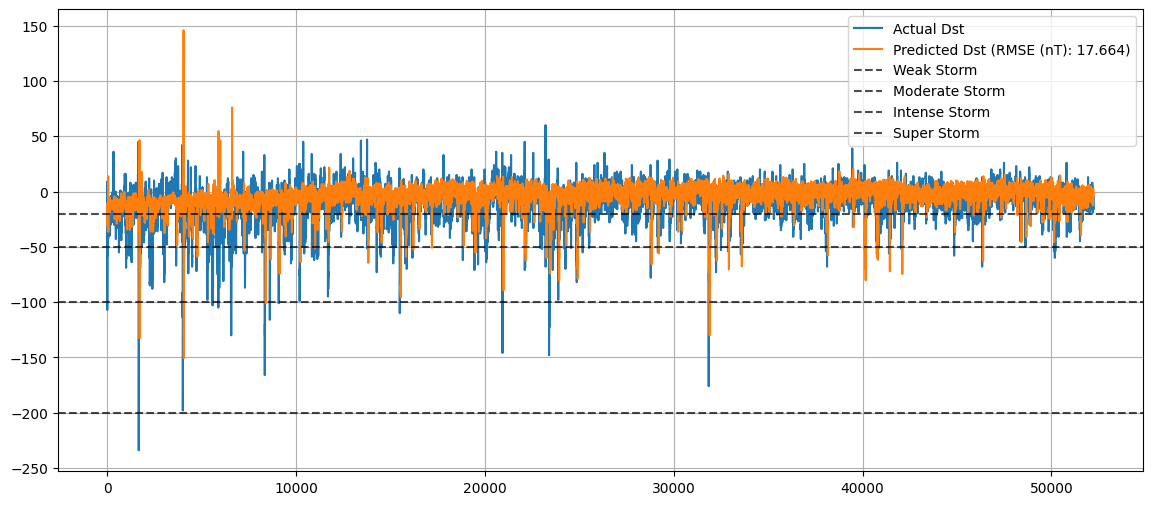

Video saved to: training_history.mp4


In [202]:
X_WINDOW_SIZE = 96
HORIZON = 48
BATCH_SIZE = 512
INITIAL_LR = 0.001
MAX_EPOCHES = 3000
PATIENCE = 10
PATIENCE_DELTA = 0.004

train_dataset = CosmicRayDataset(df=train_data_scaled, X_window_size=X_WINDOW_SIZE, horizon=HORIZON)
val_dataset = CosmicRayDataset(df=val_data_scaled, X_window_size=X_WINDOW_SIZE, horizon=HORIZON)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=True)

model = HRegressor(
    lstm_input_size=16,
    lstm_hidden_size=50,
    lstm_num_layers=1,
    lstm_dropout=0.0,
    dst_attention_heads=16,
    forecasts_len=1
).to(device)
loss_fn = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=INITIAL_LR) 
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.75, patience=5)
print(sum(i.numel() for i in model.parameters()))

result = train_cycle(
    train_loader=train_loader,
    val_loader=val_loader,
    model=model,
    loss_fn=loss_fn,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    dst_only_scaler=dst_only_scaler,
    max_epochs=MAX_EPOCHES,
    patience=PATIENCE,
    patience_delta=PATIENCE_DELTA,
)

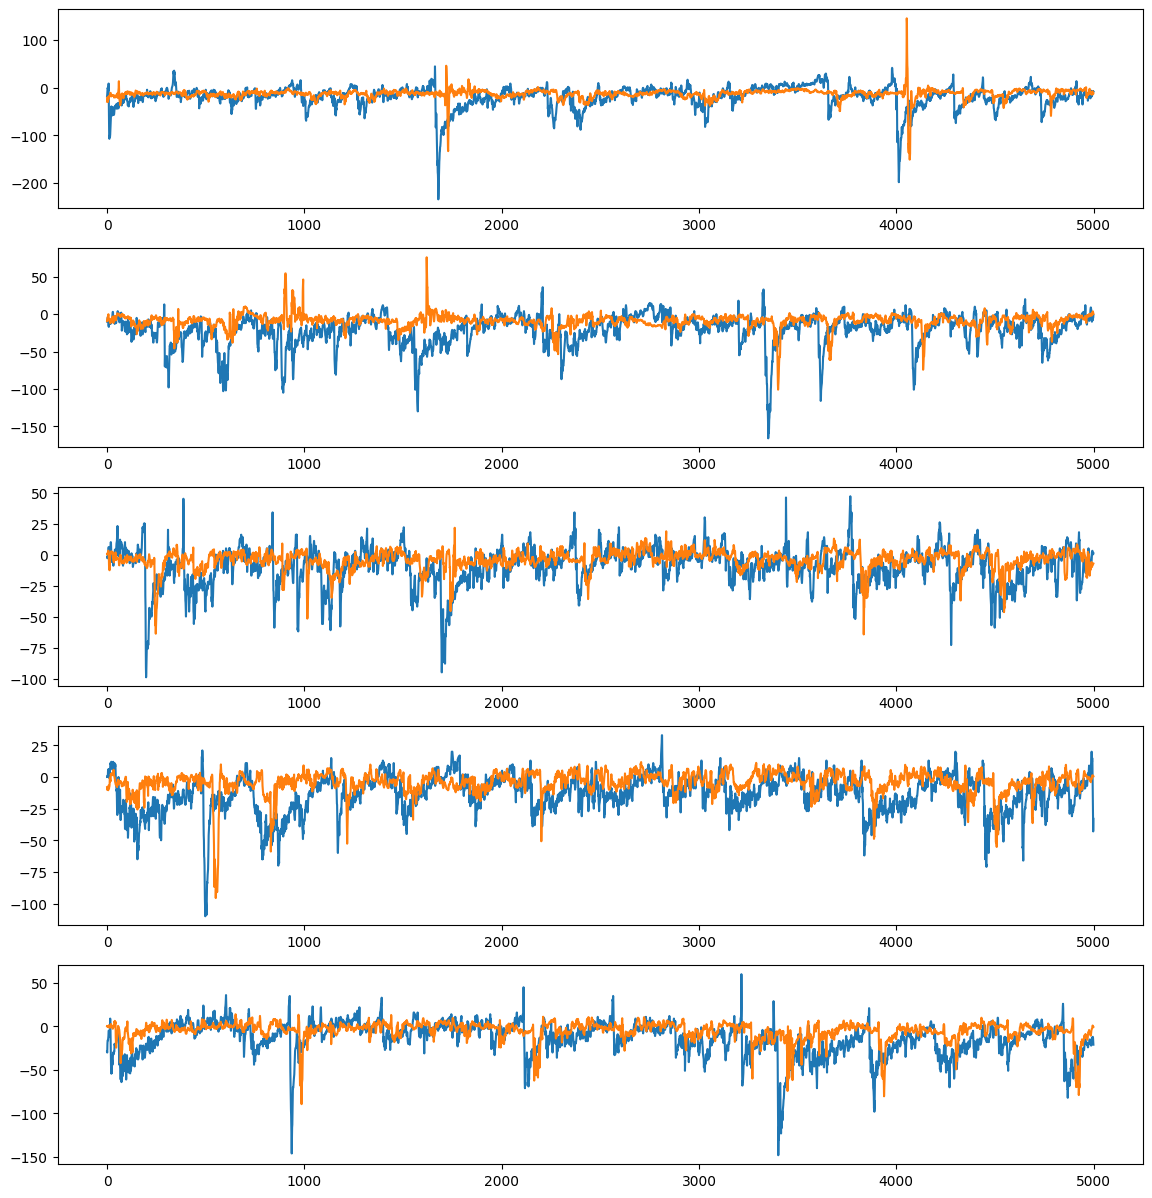

In [204]:
_, axes = plt.subplots(5, 1, figsize=(14, 15))
axes = axes.flatten()

predict = result[1]
target = result[2]
for id, i in enumerate([
    (0, 5000),
    (5000, 10000),
    (10000, 15000),
    (15000, 20000),
    (20000, 25000),
    ]):
    start, end = i
    axes[id].plot(target[start:end])
    axes[id].plot(predict[start:end])


17421
New best RMSE model! val_rmse (nT): 88.581
New best F1 model! val_f1 (macro): 0.187
New best RMSE model! val_rmse (nT): 88.493
New best RMSE model! val_rmse (nT): 68.630
New best RMSE model! val_rmse (nT): 55.022
New best RMSE model! val_rmse (nT): 48.255
New best RMSE model! val_rmse (nT): 42.987
New best RMSE model! val_rmse (nT): 39.662
New best RMSE model! val_rmse (nT): 35.278
New best F1 model! val_f1 (macro): 0.189
New best RMSE model! val_rmse (nT): 31.484
New best F1 model! val_f1 (macro): 0.191
Epoch 10: train_loss=0.001740, val_loss=0.003981, val_rmse (nT)=31.484, val_f1=0.191, lr=0.001000
New best RMSE model! val_rmse (nT): 28.298
New best F1 model! val_f1 (macro): 0.192
New best RMSE model! val_rmse (nT): 25.867
New best F1 model! val_f1 (macro): 0.193
New best RMSE model! val_rmse (nT): 24.039
New best F1 model! val_f1 (macro): 0.194
New best RMSE model! val_rmse (nT): 22.571
New best F1 model! val_f1 (macro): 0.196
New best RMSE model! val_rmse (nT): 21.920
New bes

/home/zorinep/workdir/practice-2026/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/zorinep/workdir/practice-2026/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/zorinep/workdir/practice-2026/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 


Best F1 model - F1 (macro): 0.208
Classification report (Best F1):
              precision    recall  f1-score   support

           0      0.788     0.954     0.863     40378
           1      0.359     0.113     0.172     10552
           2      0.500     0.002     0.003      1170
           3      0.000     0.000     0.000       121
           4      0.000     0.000     0.000         3

    accuracy                          0.760     52224
   macro avg      0.329     0.214     0.208     52224
weighted avg      0.693     0.760     0.702     52224



/home/zorinep/workdir/practice-2026/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/zorinep/workdir/practice-2026/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/zorinep/workdir/practice-2026/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 

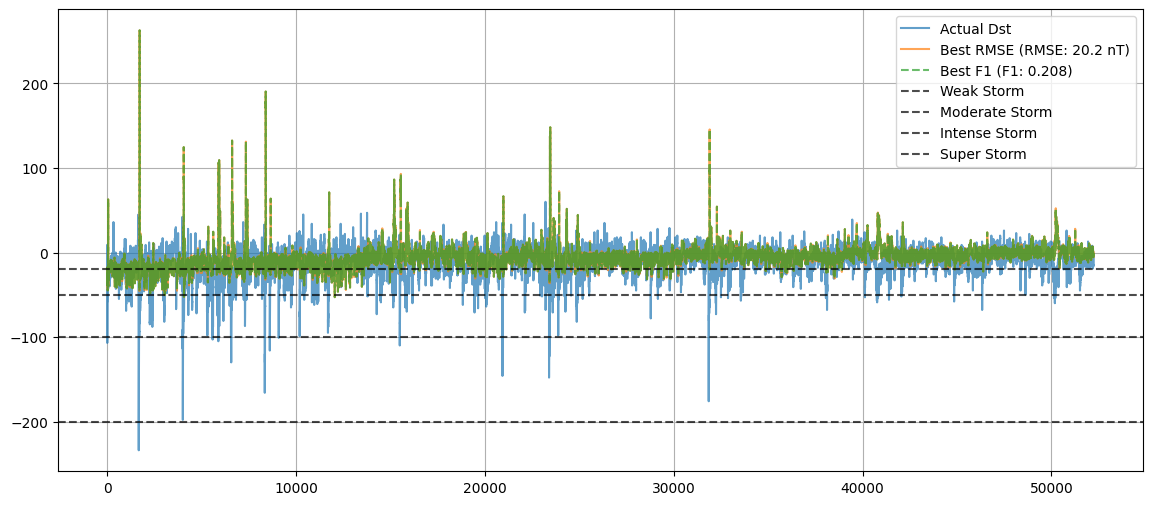

Video saved to: training_history.mp4


In [38]:
X_WINDOW_SIZE = 96
HORIZON = 48
BATCH_SIZE = 512
INITIAL_LR = 0.001
MAX_EPOCHES = 30000
PATIENCE = 30
PATIENCE_DELTA = 0.001

train_dataset = CosmicRayDataset(df=train_data_scaled, X_window_size=X_WINDOW_SIZE, horizon=HORIZON)
val_dataset = CosmicRayDataset(df=val_data_scaled, X_window_size=X_WINDOW_SIZE, horizon=HORIZON)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=True)

model = HRegressor(
    lstm_input_size=16,
    lstm_hidden_size=50,
    lstm_num_layers=1,
    lstm_dropout=0.0,
    dst_attention_heads=2,
    forecasts_len=1
).to(device)
loss_fn = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=INITIAL_LR) 
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.75, patience=10)
print(sum(i.numel() for i in model.parameters()))

result = train_cycle(
    train_loader=train_loader,
    val_loader=val_loader,
    model=model,
    loss_fn=loss_fn,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    dst_only_scaler=dst_only_scaler,
    max_epochs=MAX_EPOCHES,
    patience=PATIENCE,
    patience_delta=PATIENCE_DELTA,
)

In [54]:
torch.save(model.state_dict(), "last.pt")

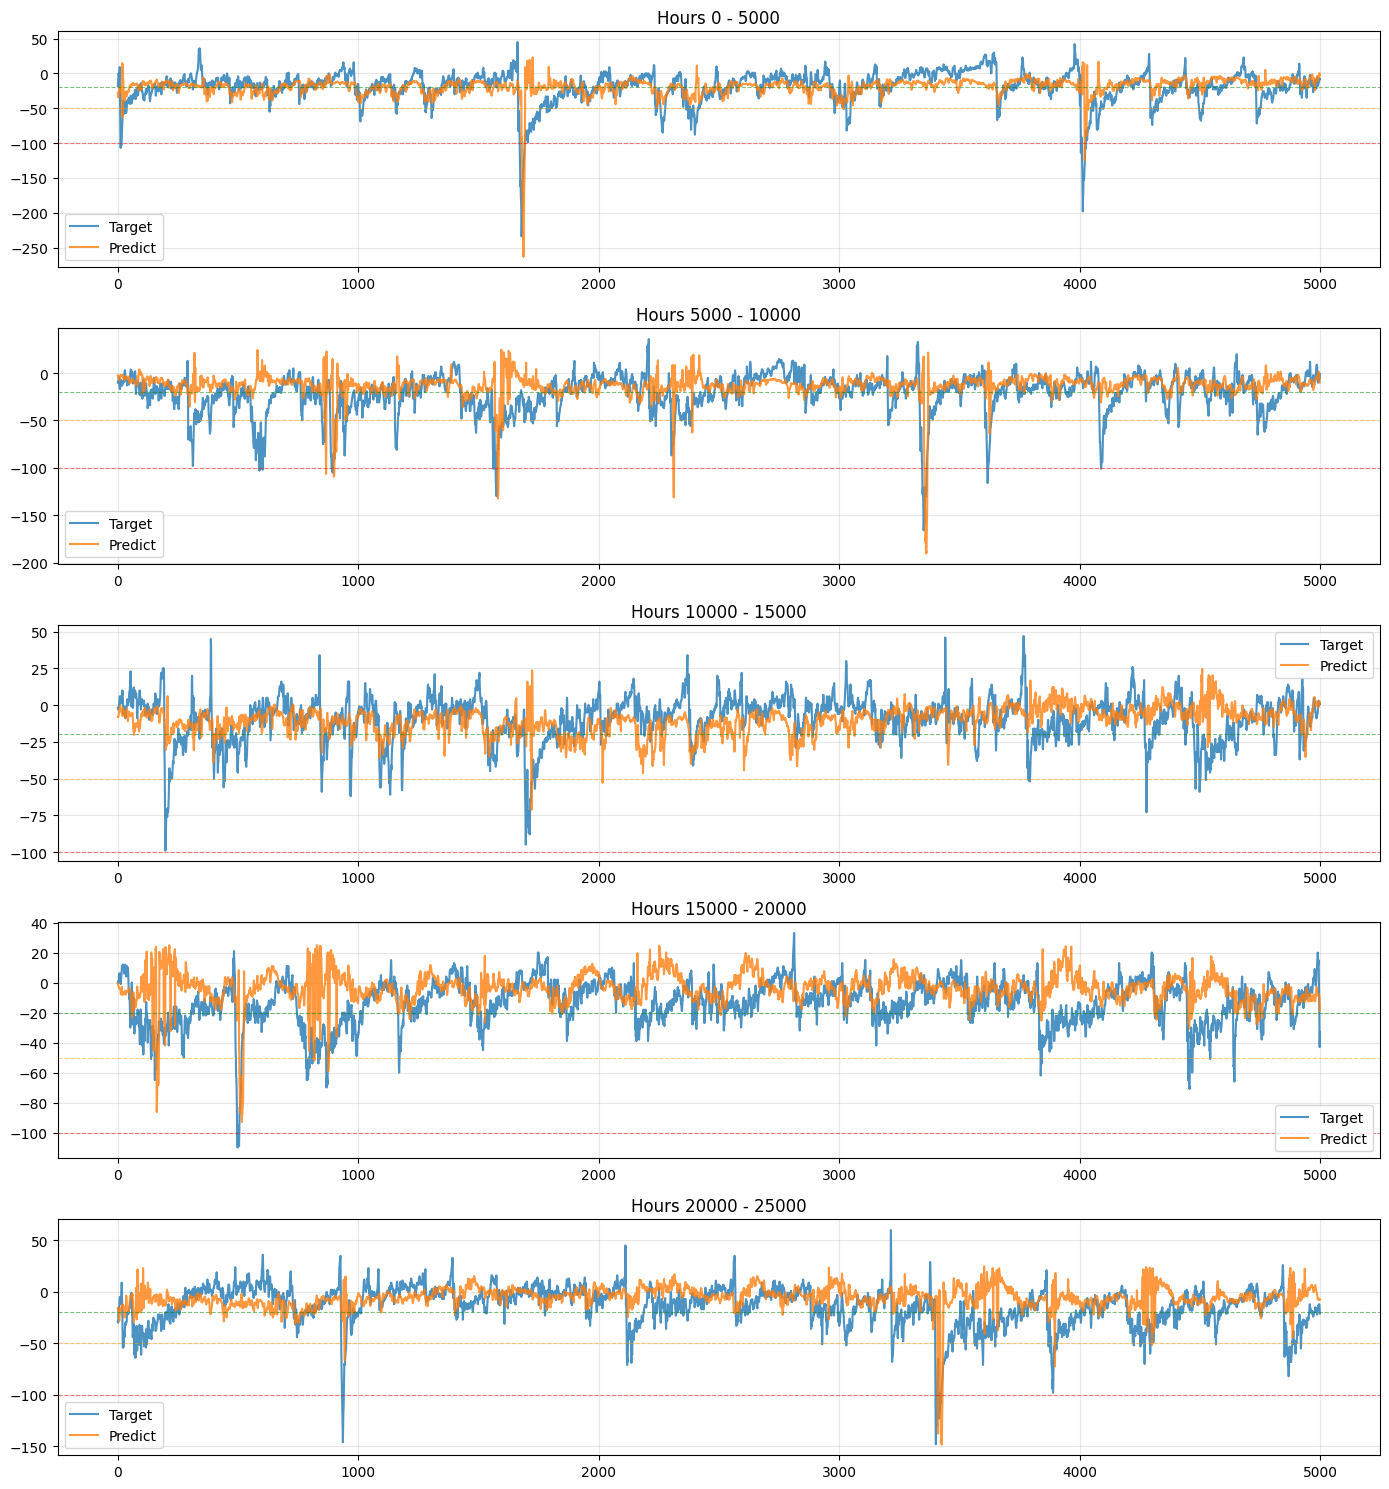

In [53]:
_, axes = plt.subplots(5, 1, figsize=(14, 15))
axes = axes.flatten()
lag = 40

predict = result[1].copy()
target = result[2][:-lag]

# Исправляем выбросы: если предсказание > 50, инвертируем знак
predict[predict > 25] = -predict[predict > 25]
predict = predict[lag:]
for id, i in enumerate([
    (0, 5000),
    (5000, 10000),
    (10000, 15000),
    (15000, 20000),
    (20000, 25000),
]):
    start, end = i
    axes[id].plot(target[start:end], label="Target", alpha=0.8)
    axes[id].plot(predict[start:end], label="Predict", alpha=0.8)
    axes[id].axhline(y=-20, color='green', linestyle='--', alpha=0.5, linewidth=0.8)
    axes[id].axhline(y=-50, color='orange', linestyle='--', alpha=0.5, linewidth=0.8)
    axes[id].axhline(y=-100, color='red', linestyle='--', alpha=0.5, linewidth=0.8)
    axes[id].set_title(f"Hours {start} - {end}")
    axes[id].legend()
    axes[id].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:

predict = result[1].copy()
target = result[2]

predict[predict > 25] = -predict[predict > 25]
print(classification_report(labeld_data(target), labeld_data(predict)))

              precision    recall  f1-score   support

           0       0.79      0.95      0.87     40378
           1       0.40      0.14      0.21     10552
           2       0.20      0.02      0.04      1170
           3       0.00      0.00      0.00       121
           4       0.00      0.00      0.00         3

    accuracy                           0.76     52224
   macro avg       0.28      0.22      0.22     52224
weighted avg       0.70      0.76      0.71     52224



17421
New best RMSE model! val_rmse (nT): 117.115
New best F1 model! val_f1 (macro): 0.187
New best RMSE model! val_rmse (nT): 94.309
New best RMSE model! val_rmse (nT): 68.002
New best F1 model! val_f1 (macro): 0.218
New best RMSE model! val_rmse (nT): 52.547
New best F1 model! val_f1 (macro): 0.228
New best RMSE model! val_rmse (nT): 45.616
New best RMSE model! val_rmse (nT): 42.991
New best F1 model! val_f1 (macro): 0.264
New best RMSE model! val_rmse (nT): 41.168
New best F1 model! val_f1 (macro): 0.311
New best RMSE model! val_rmse (nT): 38.549
New best F1 model! val_f1 (macro): 0.324
New best RMSE model! val_rmse (nT): 34.658
New best F1 model! val_f1 (macro): 0.333
New best RMSE model! val_rmse (nT): 34.168
Epoch 10: train_loss=0.000936, val_loss=0.004688, val_rmse (nT)=34.168, val_f1=0.315, lr=0.001000
New best RMSE model! val_rmse (nT): 34.069
New best F1 model! val_f1 (macro): 0.341
New best F1 model! val_f1 (macro): 0.347
Epoch 20: train_loss=0.000760, val_loss=0.006082, val

/home/zorinep/workdir/practice-2026/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/zorinep/workdir/practice-2026/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/zorinep/workdir/practice-2026/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 


Best F1 model - F1 (macro): 0.373
Classification report (Best F1):
              precision    recall  f1-score   support

           0      0.924     0.885     0.904     40336
           1      0.574     0.657     0.612     10592
           2      0.297     0.373     0.331      1172
           3      0.500     0.008     0.016       121
           4      0.000     0.000     0.000         3

    accuracy                          0.825     52224
   macro avg      0.459     0.384     0.373     52224
weighted avg      0.838     0.825     0.830     52224



/home/zorinep/workdir/practice-2026/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/zorinep/workdir/practice-2026/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/zorinep/workdir/practice-2026/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 

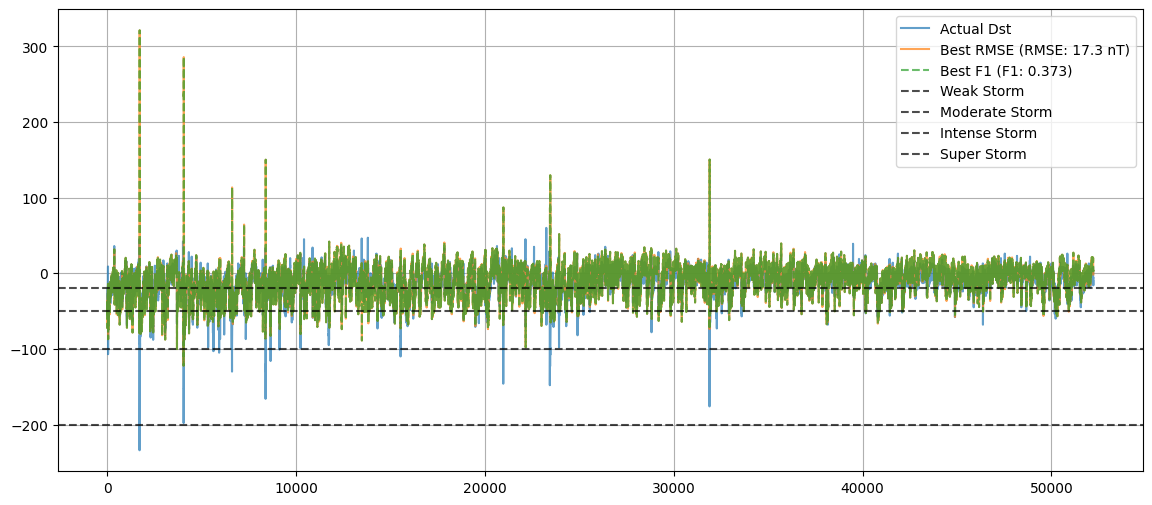

Video saved to: training_history.mp4


In [71]:
X_WINDOW_SIZE = 96
HORIZON = 6
BATCH_SIZE = 512
INITIAL_LR = 0.001
MAX_EPOCHES = 30000
PATIENCE = 30
PATIENCE_DELTA = 0.001

train_dataset = CosmicRayDataset(df=train_data_scaled, X_window_size=X_WINDOW_SIZE, horizon=HORIZON)
val_dataset = CosmicRayDataset(df=val_data_scaled, X_window_size=X_WINDOW_SIZE, horizon=HORIZON)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=True)

model = HRegressor(
    lstm_input_size=16,
    lstm_hidden_size=50,
    lstm_num_layers=1,
    lstm_dropout=0.0,
    dst_attention_heads=2,
    forecasts_len=1
).to(device)
loss_fn = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=INITIAL_LR) 
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.75, patience=10)
print(sum(i.numel() for i in model.parameters()))

result = train_cycle(
    train_loader=train_loader,
    val_loader=val_loader,
    model=model,
    loss_fn=loss_fn,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    dst_only_scaler=dst_only_scaler,
    max_epochs=MAX_EPOCHES,
    patience=PATIENCE,
    patience_delta=PATIENCE_DELTA,
)

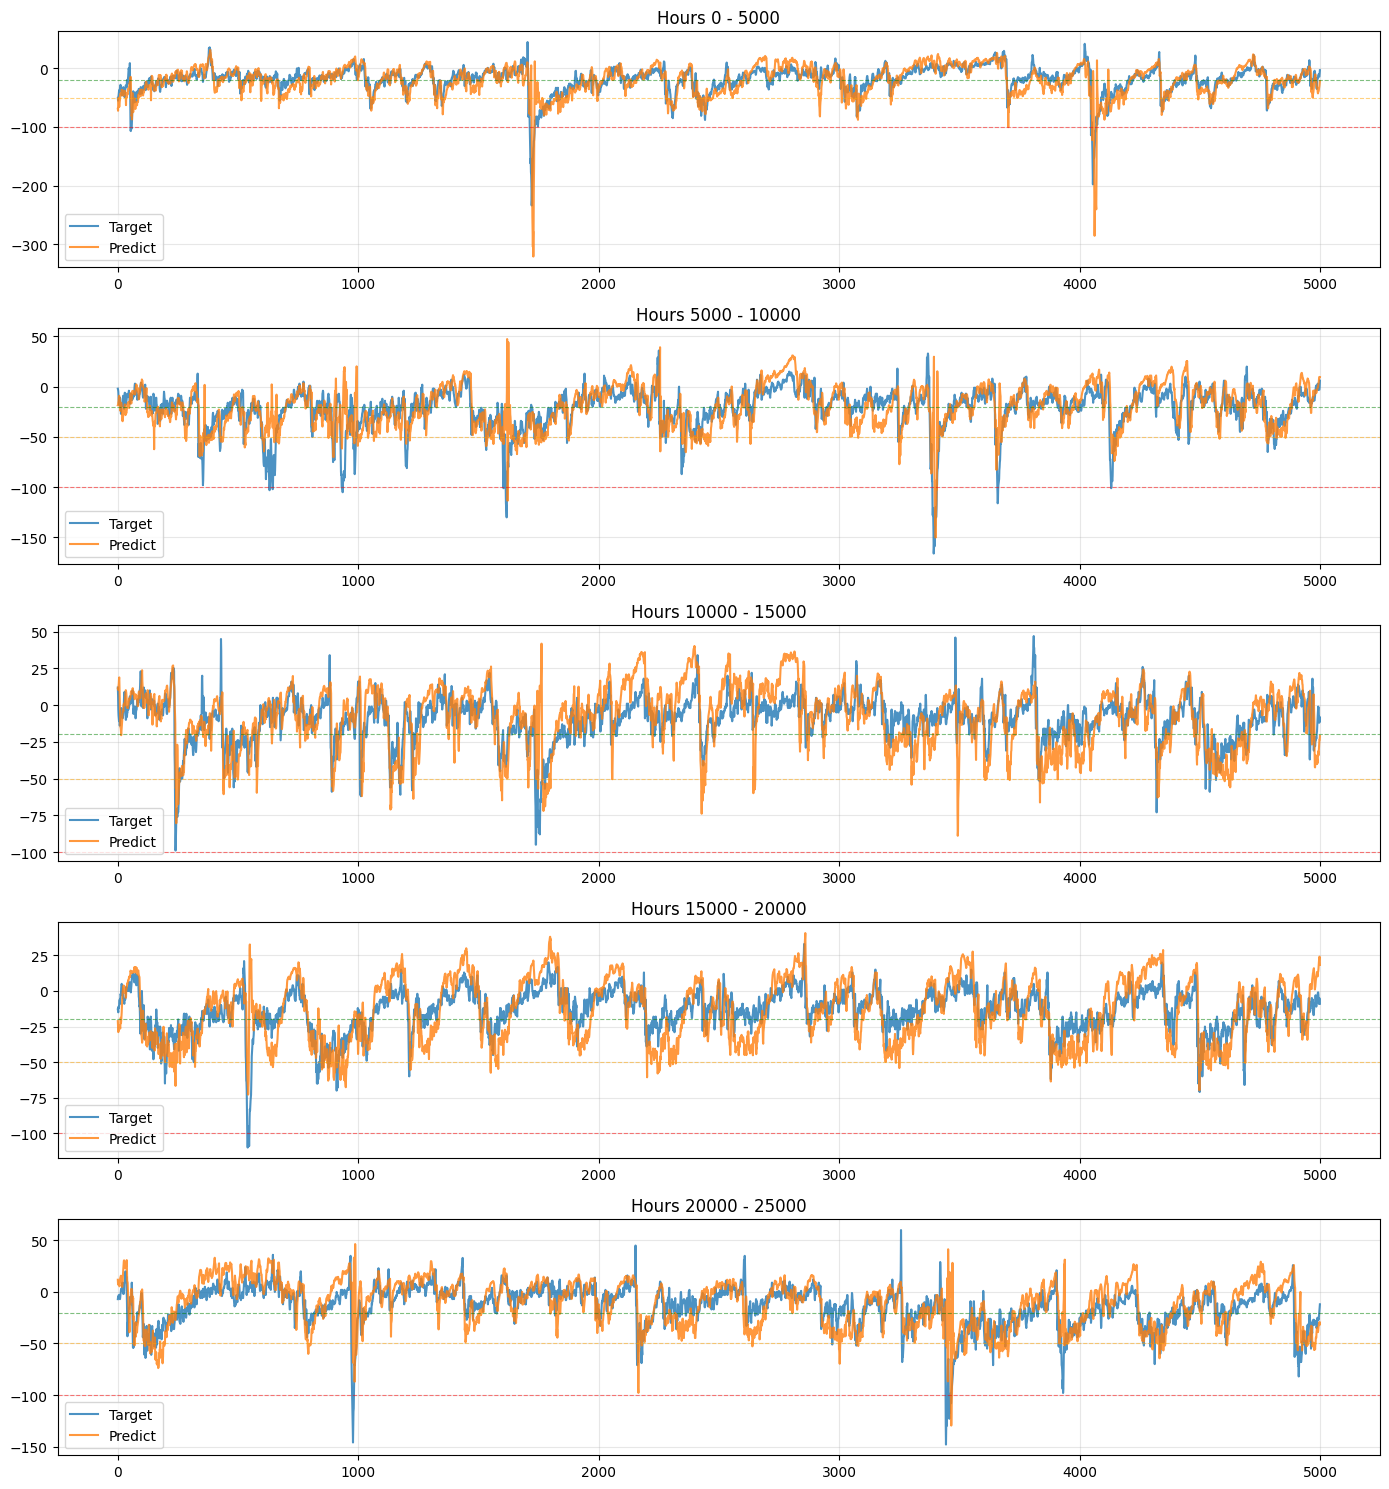

              precision    recall  f1-score   support

           0       0.93      0.88      0.90     40336
           1       0.57      0.66      0.61     10592
           2       0.30      0.39      0.34      1172
           3       0.56      0.12      0.20       121
           4       0.06      0.33      0.10         3

    accuracy                           0.83     52224
   macro avg       0.48      0.48      0.43     52224
weighted avg       0.84      0.83      0.83     52224



In [87]:
_, axes = plt.subplots(5, 1, figsize=(14, 15))
axes = axes.flatten()

predict = result[1].copy()
target = result[2]

# Исправляем выбросы: если предсказание > 50, инвертируем знак
threshold = 50
predict[predict > threshold] = -predict[predict > threshold]
for id, i in enumerate([
    (0, 5000),
    (5000, 10000),
    (10000, 15000),
    (15000, 20000),
    (20000, 25000),
]):
    start, end = i
    axes[id].plot(target[start:end], label="Target", alpha=0.8)
    axes[id].plot(predict[start:end], label="Predict", alpha=0.8)
    axes[id].axhline(y=-20, color='green', linestyle='--', alpha=0.5, linewidth=0.8)
    axes[id].axhline(y=-50, color='orange', linestyle='--', alpha=0.5, linewidth=0.8)
    axes[id].axhline(y=-100, color='red', linestyle='--', alpha=0.5, linewidth=0.8)
    axes[id].set_title(f"Hours {start} - {end}")
    axes[id].legend()
    axes[id].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(classification_report(labeld_data(target), labeld_data(predict)))

17421
New best RMSE model! val_rmse (nT): 43.780
New best F1 model! val_f1 (macro): 0.264
New best RMSE model! val_rmse (nT): 31.667
New best F1 model! val_f1 (macro): 0.279
New best RMSE model! val_rmse (nT): 30.037
New best F1 model! val_f1 (macro): 0.286
New best RMSE model! val_rmse (nT): 28.573
New best RMSE model! val_rmse (nT): 26.109
New best F1 model! val_f1 (macro): 0.316
Epoch 10: train_loss=0.000914, val_loss=0.002738, val_rmse (nT)=26.109, val_f1=0.316, lr=0.001000
New best RMSE model! val_rmse (nT): 23.062
New best F1 model! val_f1 (macro): 0.329
New best RMSE model! val_rmse (nT): 20.356
New best RMSE model! val_rmse (nT): 19.822
New best RMSE model! val_rmse (nT): 15.487
New best RMSE model! val_rmse (nT): 14.378
New best RMSE model! val_rmse (nT): 13.672
New best F1 model! val_f1 (macro): 0.340
New best RMSE model! val_rmse (nT): 12.620
New best F1 model! val_f1 (macro): 0.357
New best RMSE model! val_rmse (nT): 11.768
New best F1 model! val_f1 (macro): 0.358
Epoch 20:

/home/zorinep/workdir/practice-2026/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/zorinep/workdir/practice-2026/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/zorinep/workdir/practice-2026/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 


Best F1 model - F1 (macro): 0.358
Classification report (Best F1):
              precision    recall  f1-score   support

           0      0.885     0.910     0.897     40294
           1      0.574     0.560     0.566     10621
           2      0.459     0.157     0.234      1185
           3      0.857     0.050     0.094       121
           4      0.000     0.000     0.000         3

    accuracy                          0.820     52224
   macro avg      0.555     0.335     0.358     52224
weighted avg      0.812     0.820     0.813     52224



/home/zorinep/workdir/practice-2026/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/zorinep/workdir/practice-2026/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/zorinep/workdir/practice-2026/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 

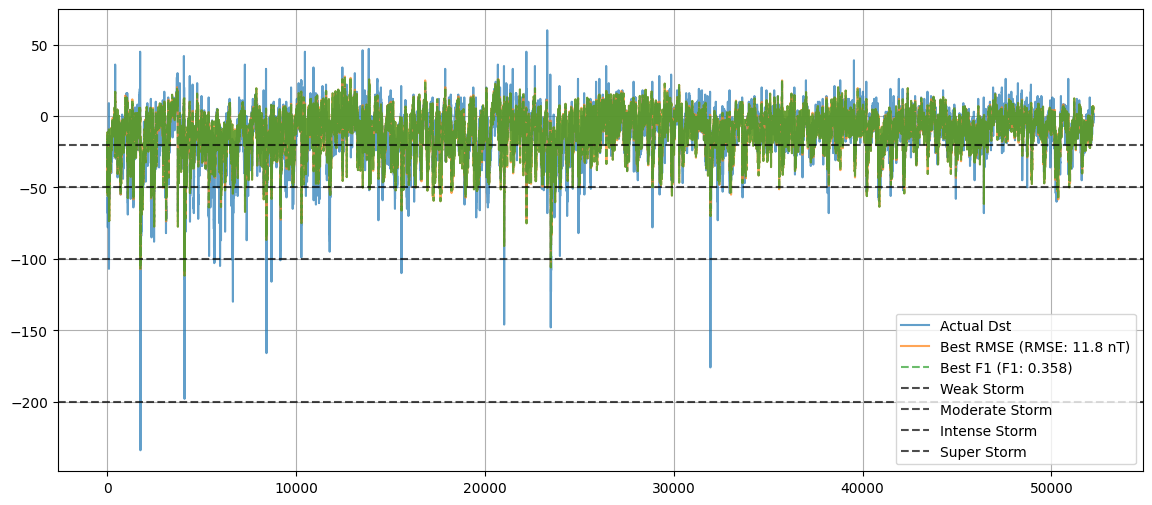

Video saved to: training_history.mp4


In [92]:
X_WINDOW_SIZE = 48
HORIZON = 6
BATCH_SIZE = 512
INITIAL_LR = 0.001
MAX_EPOCHES = 30000
PATIENCE = 30
PATIENCE_DELTA = 0.001

train_dataset = CosmicRayDataset(df=train_data_scaled, X_window_size=X_WINDOW_SIZE, horizon=HORIZON)
val_dataset = CosmicRayDataset(df=val_data_scaled, X_window_size=X_WINDOW_SIZE, horizon=HORIZON)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=True)

model = HRegressor(
    lstm_input_size=16,
    lstm_hidden_size=50,
    lstm_num_layers=1,
    lstm_dropout=0.0,
    dst_attention_heads=2,
    forecasts_len=1
).to(device)
loss_fn = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=INITIAL_LR) 
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.75, patience=10)
print(sum(i.numel() for i in model.parameters()))

result = train_cycle(
    train_loader=train_loader,
    val_loader=val_loader,
    model=model,
    loss_fn=loss_fn,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    dst_only_scaler=dst_only_scaler,
    max_epochs=MAX_EPOCHES,
    patience=PATIENCE,
    patience_delta=PATIENCE_DELTA,
)

asdasdasd

17421
New best RMSE model! val_rmse (nT): 102.976
New best F1 model! val_f1 (macro): 0.175
New best RMSE model! val_rmse (nT): 66.958
New best F1 model! val_f1 (macro): 0.180
New best RMSE model! val_rmse (nT): 61.021
New best F1 model! val_f1 (macro): 0.183
New best RMSE model! val_rmse (nT): 48.019
New best F1 model! val_f1 (macro): 0.216
New best RMSE model! val_rmse (nT): 36.962
New best F1 model! val_f1 (macro): 0.278
New best RMSE model! val_rmse (nT): 29.961
New best F1 model! val_f1 (macro): 0.377
New best RMSE model! val_rmse (nT): 28.496
New best F1 model! val_f1 (macro): 0.398
Epoch 10: train_loss=0.000988, val_loss=0.003970, val_rmse (nT)=31.440, val_f1=0.359, lr=0.001000
New best RMSE model! val_rmse (nT): 27.708
New best RMSE model! val_rmse (nT): 26.381
New best RMSE model! val_rmse (nT): 25.092
New best RMSE model! val_rmse (nT): 21.869
New best RMSE model! val_rmse (nT): 18.973
New best RMSE model! val_rmse (nT): 16.187
New best RMSE model! val_rmse (nT): 15.643
New be

/home/zorinep/workdir/practice-2026/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/zorinep/workdir/practice-2026/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/zorinep/workdir/practice-2026/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 


Best F1 model - F1 (macro): 0.398
Classification report (Best F1):
              precision    recall  f1-score   support

           0      0.826     0.989     0.900     40360
           1      0.693     0.221     0.335     10570
           2      0.657     0.262     0.375      1170
           3      0.811     0.248     0.380       121
           4      0.000     0.000     0.000         3

    accuracy                          0.816     52224
   macro avg      0.597     0.344     0.398     52224
weighted avg      0.795     0.816     0.773     52224



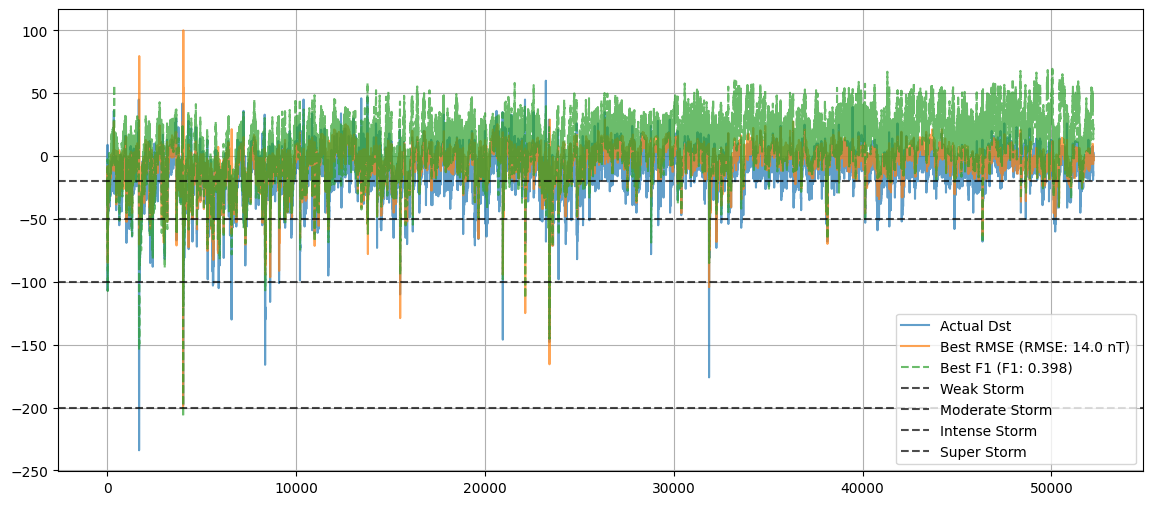

Video saved to: training_history.mp4


In [97]:
X_WINDOW_SIZE = 24*5
HORIZON = 6
BATCH_SIZE = 512
INITIAL_LR = 0.001
MAX_EPOCHES = 30000
PATIENCE = 30
PATIENCE_DELTA = 0.001

train_dataset = CosmicRayDataset(df=train_data_scaled, X_window_size=X_WINDOW_SIZE, horizon=HORIZON)
val_dataset = CosmicRayDataset(df=val_data_scaled, X_window_size=X_WINDOW_SIZE, horizon=HORIZON)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=True)

model = HRegressor(
    lstm_input_size=16,
    lstm_hidden_size=50,
    lstm_num_layers=1,
    lstm_dropout=0.0,
    dst_attention_heads=2,
    forecasts_len=1
).to(device)
loss_fn = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=INITIAL_LR) 
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.75, patience=10)
print(sum(i.numel() for i in model.parameters()))

result = train_cycle(
    train_loader=train_loader,
    val_loader=val_loader,
    model=model,
    loss_fn=loss_fn,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    dst_only_scaler=dst_only_scaler,
    max_epochs=MAX_EPOCHES,
    patience=PATIENCE,
    patience_delta=PATIENCE_DELTA,
)

In [98]:
torch.save(model.state_dict(), "best_6.pt")

In [ ]:
X_WINDOW_SIZE = 24*5
HORIZON = 6
BATCH_SIZE = 512
INITIAL_LR = 0.001
MAX_EPOCHES = 30000
PATIENCE = 30
PATIENCE_DELTA = 0.001

train_dataset = CosmicRayDataset(df=train_data_scaled, X_window_size=X_WINDOW_SIZE, horizon=HORIZON)
val_dataset = CosmicRayDataset(df=val_data_scaled, X_window_size=X_WINDOW_SIZE, horizon=HORIZON)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=True)

model = HRegressor(
    lstm_input_size=16,
    lstm_hidden_size=70,
    lstm_num_layers=1,
    lstm_dropout=0.0,
    dst_attention_heads=2,
    forecasts_len=1
).to(device)
loss_fn = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=INITIAL_LR) 
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.75, patience=10)
print(sum(i.numel() for i in model.parameters()))

result = train_cycle(
    train_loader=train_loader,
    val_loader=val_loader,
    model=model,
    loss_fn=loss_fn,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    dst_only_scaler=dst_only_scaler,
    max_epochs=MAX_EPOCHES,
    patience=PATIENCE,
    patience_delta=PATIENCE_DELTA,
)